# 📊 Statistics for Deep Learning: Zero to Hero

## A Gentle, Visual Introduction for Deep Learning Students

---

Welcome! This notebook will give you a **solid statistical foundation** for understanding deep learning. Every concept is connected to where it appears in neural networks!

### What You'll Learn

| Part | Topic | Deep Learning Connection |
|------|-------|-------------------------|
| 1 | Why Statistics? | The probabilistic view of learning |
| 2 | Descriptive Statistics | Batch normalization, weight initialization |
| 3 | Probability Fundamentals | Dropout, output layers, uncertainty |
| 4 | Probability Distributions | Weight init, noise injection, outputs |
| 5 | Expectation & Variance | Loss functions, gradient variance |
| 6 | Bayes' Theorem | Bayesian networks, uncertainty estimation |
| 7 | Maximum Likelihood | Training = MLE! Cross-entropy loss |
| 8 | Information Theory | Cross-entropy, KL divergence, VAEs |
| 9 | Sampling & Monte Carlo | SGD, dropout as sampling, MCMC |
| 10 | Covariance & Correlation | Feature relationships, attention |
| 11 | Regularization | L1/L2 as priors, Bayesian view |
| 12 | Summary | Complete picture |

### Prerequisites
- Basic Python knowledge
- High school math (algebra, basic calculus helpful)
- Curiosity! 🧠

### Philosophy
```
┌────────────────────────────────────────────────────────────────┐
│                                                                │
│   "Deep learning is applied statistics on steroids"           │
│                                                                │
│   • Neural networks learn PROBABILITY DISTRIBUTIONS           │
│   • Training is MAXIMUM LIKELIHOOD ESTIMATION                 │
│   • Loss functions come from INFORMATION THEORY               │
│   • Regularization is BAYESIAN INFERENCE                      │
│                                                                │
└────────────────────────────────────────────────────────────────┘
```

Let's begin! 🚀

---
## 🛠️ Setup

First, let's import our tools.

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import softmax

# PyTorch for deep learning examples
import torch
import torch.nn as nn
import torch.nn.functional as F

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ All libraries loaded!")
print(f"   NumPy: {np.__version__}")
print(f"   PyTorch: {torch.__version__}")

✅ All libraries loaded!
   NumPy: 2.2.6
   PyTorch: 2.14.0


In [2]:
# 🎨 Visualization Helper Functions

def plot_distribution(data, title, xlabel='Value', color='steelblue', show_stats=True):
    """Plot histogram with KDE and statistics."""
    fig, ax = plt.subplots(figsize=(10, 5))

    # Histogram with KDE
    sns.histplot(data, kde=True, color=color, ax=ax, stat='density', alpha=0.6)

    if show_stats:
        # Add vertical lines for mean and std
        mean, std = np.mean(data), np.std(data)
        ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.3f}')
        ax.axvline(mean + std, color='orange', linestyle=':', linewidth=2, label=f'+1 Std: {mean+std:.3f}')
        ax.axvline(mean - std, color='orange', linestyle=':', linewidth=2, label=f'-1 Std: {mean-std:.3f}')
        ax.legend()

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    plt.tight_layout()
    plt.show()


def compare_distributions(data_list, labels, title, colors=None):
    """Compare multiple distributions side by side."""
    fig, ax = plt.subplots(figsize=(12, 5))

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data_list)))

    for data, label, color in zip(data_list, labels, colors):
        sns.kdeplot(data, label=label, color=color, linewidth=2, ax=ax)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()


print("✅ Visualization helpers ready!")

✅ Visualization helpers ready!


---
# Part 1: Why Statistics for Deep Learning? 🤔

## The Hidden Statistical Foundation

Every time you train a neural network, you're doing **statistics** - even if you don't realize it!

```
┌────────────────────────────────────────────────────────────────┐
│           DEEP LEARNING IS STATISTICAL LEARNING                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  What you THINK you're doing:                                   │
│  "I'm training a neural network to classify images"            │
│                                                                 │
│  What you're ACTUALLY doing:                                    │
│  "I'm estimating a probability distribution P(class|image)     │
│   by maximizing the likelihood of the training data"           │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Statistical concepts hidden in deep learning:                  │
│                                                                 │
│  ┌─────────────────┐     ┌─────────────────────────────────┐  │
│  │ DL Concept      │ ══► │ Statistical Foundation          │  │
│  ├─────────────────┤     ├─────────────────────────────────┤  │
│  │ Softmax output  │     │ Probability distribution        │  │
│  │ Cross-entropy   │     │ Negative log-likelihood         │  │
│  │ SGD             │     │ Stochastic optimization         │  │
│  │ Dropout         │     │ Monte Carlo sampling            │  │
│  │ Batch norm      │     │ Standardization (z-scores)      │  │
│  │ Weight decay    │     │ Gaussian prior (L2 = MAP)       │  │
│  │ Data augment    │     │ Distribution shift robustness   │  │
│  └─────────────────┘     └─────────────────────────────────┘  │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## The Three Pillars

### 1. **Probability** - Uncertainty is everywhere!
Neural networks output probabilities, not certainties.

### 2. **Estimation** - Learning from limited data
We have finite samples but want to generalize to the whole world.

### 3. **Optimization** - Finding the best model
Training = finding parameters that maximize likelihood.

🧠 Neural Network Output Analysis

Raw logits (before softmax): [0.34026334 0.01807025 0.29704493]
Probabilities (after softmax): [0.37281987 0.2701297  0.35705042]

Sum of probabilities: 1.000000
Predicted class: 0


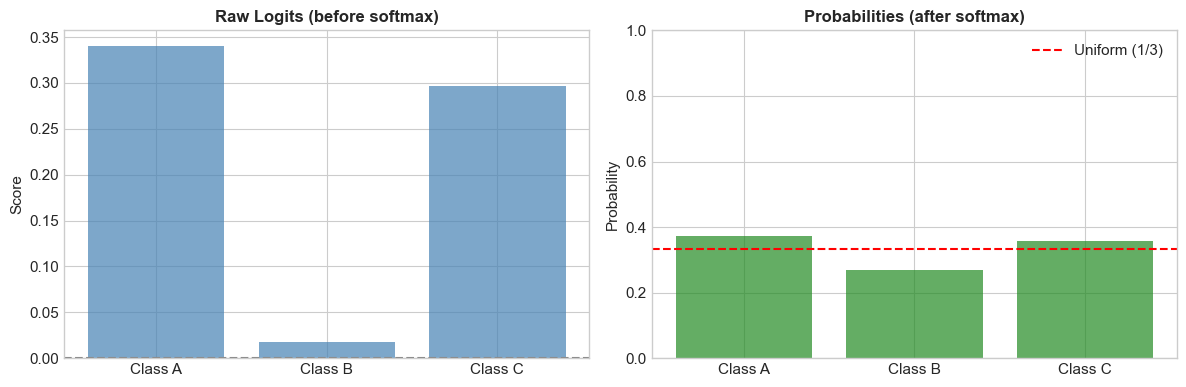


💡 Key Insight: Softmax transforms arbitrary scores into a valid probability distribution!


In [3]:
# 🎯 Demo: Neural Network Outputs are Probability Distributions!

# A simple neural network classifier
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim=10, num_classes=3):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        logits = self.fc(x)
        # Softmax converts raw scores to PROBABILITIES!
        probabilities = F.softmax(logits, dim=-1)
        return logits, probabilities

# Create model and dummy input
model = SimpleClassifier()
x = torch.randn(1, 10)  # Random input

logits, probs = model(x)

print("🧠 Neural Network Output Analysis")
print("=" * 50)
print(f"\nRaw logits (before softmax): {logits.detach().numpy().flatten()}")
print(f"Probabilities (after softmax): {probs.detach().numpy().flatten()}")
print(f"\nSum of probabilities: {probs.sum().item():.6f}")  # Should be 1.0!
print(f"Predicted class: {probs.argmax().item()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

classes = ['Class A', 'Class B', 'Class C']

# Logits (raw scores)
axes[0].bar(classes, logits.detach().numpy().flatten(), color='steelblue', alpha=0.7)
axes[0].set_title('Raw Logits (before softmax)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].axhline(y=0, color='gray', linestyle='--')

# Probabilities
axes[1].bar(classes, probs.detach().numpy().flatten(), color='forestgreen', alpha=0.7)
axes[1].set_title('Probabilities (after softmax)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=1/3, color='red', linestyle='--', label='Uniform (1/3)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Softmax transforms arbitrary scores into a valid probability distribution!")

---
# Part 2: Descriptive Statistics 📈

## The Building Blocks: Mean, Variance, and Standard Deviation

These three concepts appear EVERYWHERE in deep learning!

```
┌────────────────────────────────────────────────────────────────┐
│           THE HOLY TRINITY OF STATISTICS                        │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  MEAN (μ) - The Center                                         │
│  ────────────────────────                                      │
│  μ = (1/n) Σ xᵢ                                                │
│                                                                 │
│  "Where is the typical value?"                                 │
│                                                                 │
│  Deep Learning uses:                                            │
│  • Batch Normalization: centers activations                    │
│  • Weight initialization: mean = 0                             │
│  • Running averages in optimizers                              │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  VARIANCE (σ²) - The Spread (squared)                          │
│  ─────────────────────────────────────                         │
│  σ² = (1/n) Σ (xᵢ - μ)²                                        │
│                                                                 │
│  "How spread out are the values?"                              │
│                                                                 │
│  Deep Learning uses:                                            │
│  • Gradient variance affects training stability                │
│  • Feature scaling importance                                  │
│  • Variance in weight initialization                           │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  STANDARD DEVIATION (σ) - The Spread (same units)              │
│  ─────────────────────────────────────────────────             │
│  σ = √(σ²)                                                     │
│                                                                 │
│  "Same as variance but in original units"                      │
│                                                                 │
│  Deep Learning uses:                                            │
│  • Batch Norm divides by std                                   │
│  • He/Xavier initialization uses √(2/n)                        │
│  • Confidence intervals                                        │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## Why Does This Matter for Deep Learning?

**Problem:** If layer activations get too large or too small, gradients explode or vanish!

**Solution:** Keep activations centered (mean ≈ 0) and scaled (std ≈ 1)

📊 Descriptive Statistics

Data: 1000 samples from Normal distribution

Manual calculations:
  Mean (μ) = Σxᵢ/n = 5.0387
  Variance (σ²) = Σ(xᵢ-μ)²/n = 3.8316
  Std Dev (σ) = √variance = 1.9575

NumPy calculations (for verification):
  np.mean() = 5.0387
  np.var() = 3.8316
  np.std() = 1.9575


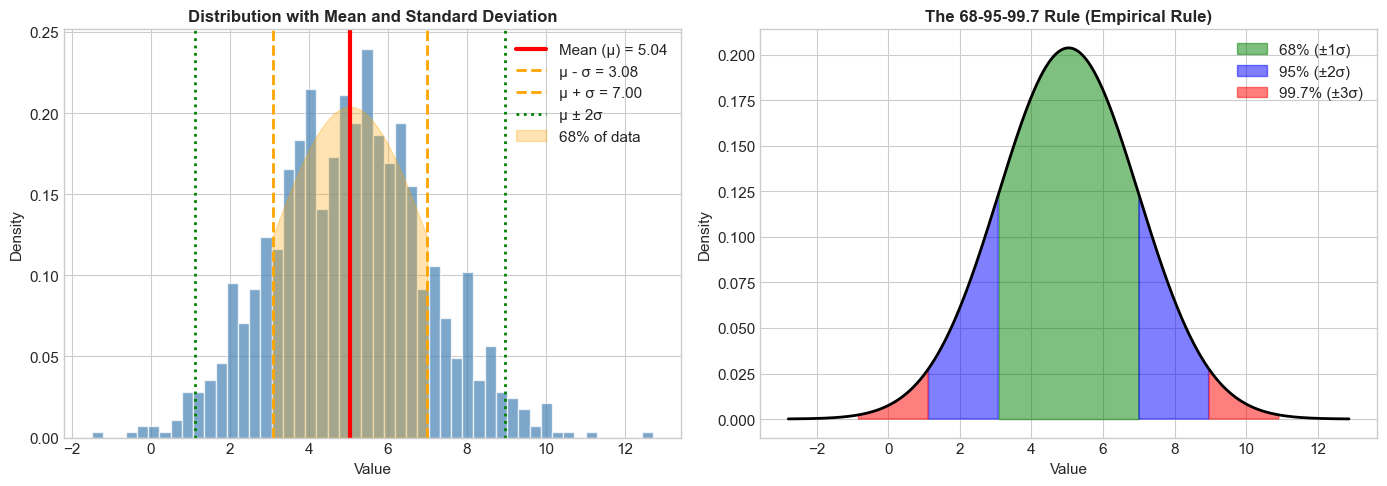


💡 The 68-95-99.7 Rule:
   • 68% of data falls within ±1 standard deviation
   • 95% of data falls within ±2 standard deviations
   • 99.7% of data falls within ±3 standard deviations


In [4]:
# 📊 Visualizing Mean, Variance, and Standard Deviation

# Generate sample data
np.random.seed(42)
data = np.random.normal(loc=5, scale=2, size=1000)  # Mean=5, Std=2

# Calculate statistics manually (to understand the formulas)
n = len(data)
mean = np.sum(data) / n
variance = np.sum((data - mean)**2) / n
std = np.sqrt(variance)

print("📊 Descriptive Statistics")
print("=" * 50)
print(f"\nData: {n} samples from Normal distribution")
print(f"\nManual calculations:")
print(f"  Mean (μ) = Σxᵢ/n = {mean:.4f}")
print(f"  Variance (σ²) = Σ(xᵢ-μ)²/n = {variance:.4f}")
print(f"  Std Dev (σ) = √variance = {std:.4f}")
print(f"\nNumPy calculations (for verification):")
print(f"  np.mean() = {np.mean(data):.4f}")
print(f"  np.var() = {np.var(data):.4f}")
print(f"  np.std() = {np.std(data):.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution with mean and std
ax = axes[0]
ax.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')

# Add lines for mean and std ranges
ax.axvline(mean, color='red', linestyle='-', linewidth=3, label=f'Mean (μ) = {mean:.2f}')
ax.axvline(mean - std, color='orange', linestyle='--', linewidth=2, label=f'μ - σ = {mean-std:.2f}')
ax.axvline(mean + std, color='orange', linestyle='--', linewidth=2, label=f'μ + σ = {mean+std:.2f}')
ax.axvline(mean - 2*std, color='green', linestyle=':', linewidth=2, label=f'μ ± 2σ')
ax.axvline(mean + 2*std, color='green', linestyle=':', linewidth=2)

# Shade the 68% region (within 1 std)
x_fill = np.linspace(mean - std, mean + std, 100)
y_fill = stats.norm.pdf(x_fill, mean, std)
ax.fill_between(x_fill, y_fill, alpha=0.3, color='orange', label='68% of data')

ax.set_title('Distribution with Mean and Standard Deviation', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend(loc='upper right')

# Right: The 68-95-99.7 rule
ax = axes[1]
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
y = stats.norm.pdf(x, mean, std)

ax.plot(x, y, 'k-', linewidth=2)
ax.fill_between(x, y, where=(x >= mean-std) & (x <= mean+std), alpha=0.5, color='green', label='68% (±1σ)')
ax.fill_between(x, y, where=(x >= mean-2*std) & (x <= mean+2*std) & ((x < mean-std) | (x > mean+std)),
                alpha=0.5, color='blue', label='95% (±2σ)')
ax.fill_between(x, y, where=(x >= mean-3*std) & (x <= mean+3*std) & ((x < mean-2*std) | (x > mean+2*std)),
                alpha=0.5, color='red', label='99.7% (±3σ)')

ax.set_title('The 68-95-99.7 Rule (Empirical Rule)', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

print("\n💡 The 68-95-99.7 Rule:")
print("   • 68% of data falls within ±1 standard deviation")
print("   • 95% of data falls within ±2 standard deviations")
print("   • 99.7% of data falls within ±3 standard deviations")

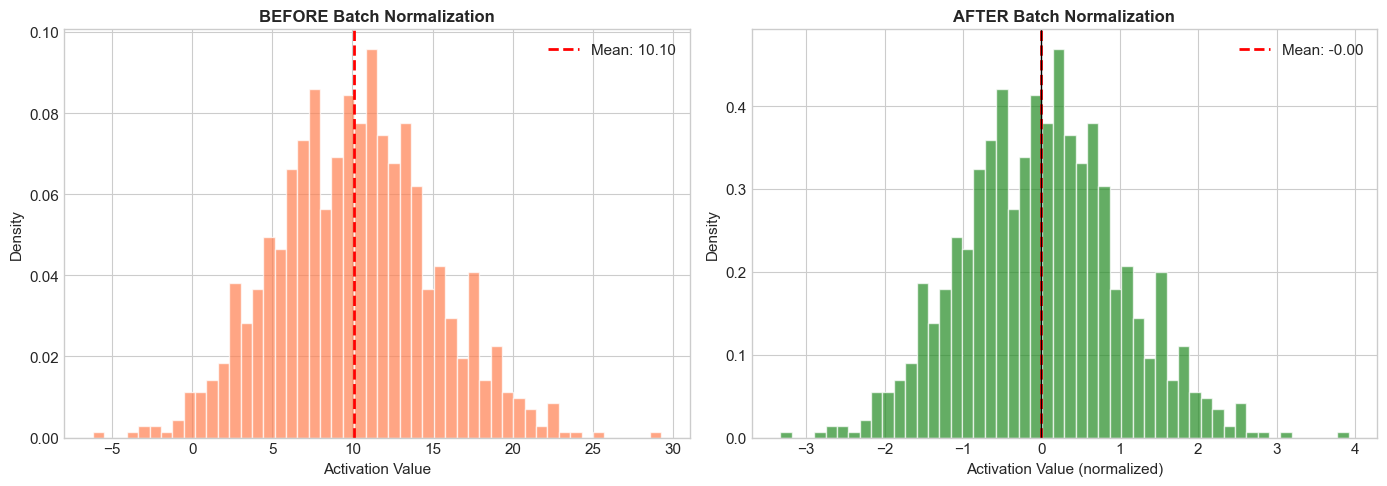

📊 Batch Normalization Statistics

BEFORE:
  Mean: 10.0967
  Std:  4.8936

AFTER:
  Mean: -0.0000 (≈ 0)
  Std:  1.0000 (≈ 1)

💡 Why Batch Normalization Helps:
   1. Prevents activations from getting too large → stable gradients
   2. Prevents activations from getting too small → signal preserved
   3. Allows higher learning rates → faster training
   4. Acts as mild regularization → better generalization


In [5]:
# 🧠 Deep Learning Connection: Batch Normalization
# BatchNorm uses mean and std to normalize activations!

def batch_normalize(x, eps=1e-5):
    """
    Batch Normalization (simplified version)

    This is exactly what happens inside nn.BatchNorm!

    Formula: x_norm = (x - μ) / σ

    Result: Mean ≈ 0, Std ≈ 1
    """
    mean = x.mean()
    std = x.std()
    x_normalized = (x - mean) / (std + eps)
    return x_normalized, mean, std


# Simulate layer activations (before normalization)
np.random.seed(42)
activations_before = np.random.normal(loc=10, scale=5, size=1000)  # Mean=10, Std=5

# Apply batch normalization
activations_after, mean, std = batch_normalize(activations_before)

# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before BatchNorm
ax = axes[0]
ax.hist(activations_before, bins=50, density=True, alpha=0.7, color='coral', edgecolor='white')
ax.axvline(activations_before.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {activations_before.mean():.2f}')
ax.set_title('BEFORE Batch Normalization', fontsize=12, fontweight='bold')
ax.set_xlabel('Activation Value')
ax.set_ylabel('Density')
ax.legend()

# After BatchNorm
ax = axes[1]
ax.hist(activations_after, bins=50, density=True, alpha=0.7, color='forestgreen', edgecolor='white')
ax.axvline(activations_after.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {activations_after.mean():.2f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('AFTER Batch Normalization', fontsize=12, fontweight='bold')
ax.set_xlabel('Activation Value (normalized)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

print("📊 Batch Normalization Statistics")
print("=" * 50)
print(f"\nBEFORE:")
print(f"  Mean: {activations_before.mean():.4f}")
print(f"  Std:  {activations_before.std():.4f}")
print(f"\nAFTER:")
print(f"  Mean: {activations_after.mean():.4f} (≈ 0)")
print(f"  Std:  {activations_after.std():.4f} (≈ 1)")

print("\n💡 Why Batch Normalization Helps:")
print("   1. Prevents activations from getting too large → stable gradients")
print("   2. Prevents activations from getting too small → signal preserved")
print("   3. Allows higher learning rates → faster training")
print("   4. Acts as mild regularization → better generalization")

---
# Part 3: Probability Fundamentals 🎲

## What is Probability?

Probability measures how likely something is to happen. It's the language of uncertainty!

```
┌────────────────────────────────────────────────────────────────┐
│                    PROBABILITY BASICS                           │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  P(A) = Probability of event A                                 │
│                                                                 │
│  Properties:                                                    │
│  • 0 ≤ P(A) ≤ 1         (always between 0 and 1)               │
│  • P(certain) = 1        (something must happen)               │
│  • P(impossible) = 0     (can't happen)                        │
│  • Σ P(all outcomes) = 1 (must add up to 1)                    │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  KEY FORMULAS FOR DEEP LEARNING:                                │
│                                                                 │
│  Joint Probability:                                             │
│  P(A and B) = P(A, B) = P(A|B) × P(B)                          │
│                                                                 │
│  Conditional Probability:                                       │
│  P(A|B) = P(A and B) / P(B)                                    │
│  "Probability of A GIVEN that B happened"                       │
│                                                                 │
│  Chain Rule:                                                    │
│  P(A, B, C) = P(A|B,C) × P(B|C) × P(C)                         │
│  (Used in autoregressive models like GPT!)                     │
│                                                                 │
│  Marginalization:                                               │
│  P(A) = Σ P(A, B) over all values of B                         │
│  "Sum out" variables we don't care about                       │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## Deep Learning Connection: Conditional Probability

**Classification:** We want P(class | image)
- "What's the probability of 'cat' given this image?"

**Language Models:** We want P(next word | previous words)
- "What's the probability of 'world' given 'Hello'"?

**Generative Models:** We want P(image | description)
- "Generate an image given 'a sunset over mountains'"

🎲 From Logits to Probabilities

Neural network output (logits):
  Cat: 2.10
  Dog: 0.80
  Bird: -0.50

After Softmax (probabilities):
  P(Cat | image) = 0.7425 (74.2%)
  P(Dog | image) = 0.2024 (20.2%)
  P(Bird | image) = 0.0551 (5.5%)

Sum of probabilities: 1.000000 ✓


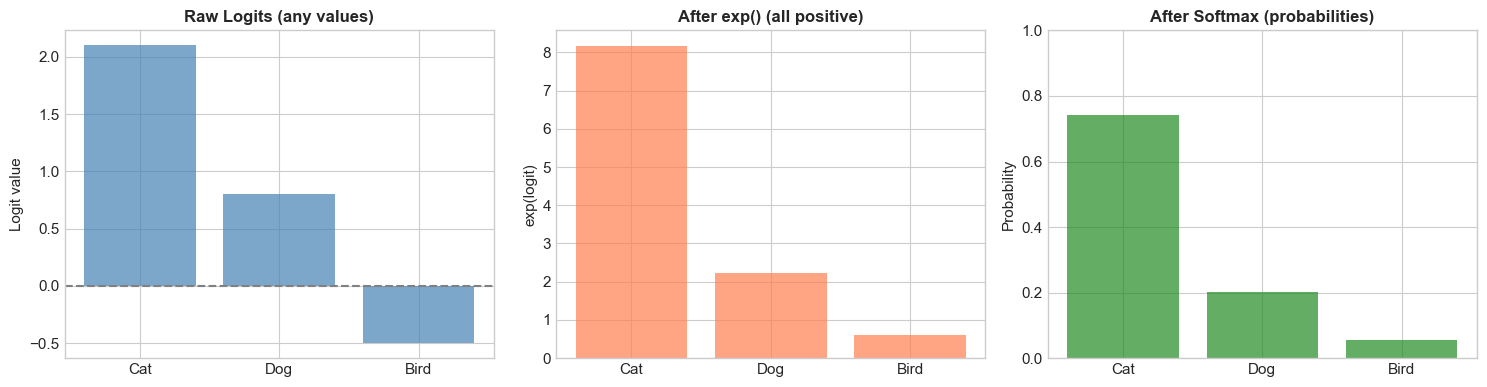


💡 Softmax is the bridge between neural network outputs and probabilities!
   It's used in the output layer of almost every classification network.


In [6]:
# 🎲 Probability Fundamentals - Interactive Demo

# Let's visualize probability with a simple example
# Imagine a classifier for animals: cat, dog, bird

# Simulated predictions for one image (logits from neural network)
logits = np.array([2.1, 0.8, -0.5])  # Raw scores
classes = ['Cat', 'Dog', 'Bird']

# Convert to probabilities using SOFTMAX
def softmax(x):
    """
    Softmax converts any vector into a valid probability distribution.

    Formula: P(class_i) = exp(x_i) / Σ exp(x_j)

    Properties:
    - All values between 0 and 1
    - Sum equals 1
    """
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / exp_x.sum()

probabilities = softmax(logits)

print("🎲 From Logits to Probabilities")
print("=" * 50)
print("\nNeural network output (logits):")
for cls, logit in zip(classes, logits):
    print(f"  {cls}: {logit:.2f}")

print("\nAfter Softmax (probabilities):")
for cls, prob in zip(classes, probabilities):
    print(f"  P({cls} | image) = {prob:.4f} ({prob*100:.1f}%)")

print(f"\nSum of probabilities: {probabilities.sum():.6f} ✓")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Raw logits
axes[0].bar(classes, logits, color='steelblue', alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='--')
axes[0].set_title('Raw Logits (any values)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Logit value')

# 2. After exponential
exp_logits = np.exp(logits)
axes[1].bar(classes, exp_logits, color='coral', alpha=0.7)
axes[1].set_title('After exp() (all positive)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('exp(logit)')

# 3. After normalization (softmax)
axes[2].bar(classes, probabilities, color='forestgreen', alpha=0.7)
axes[2].set_title('After Softmax (probabilities)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Probability')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n💡 Softmax is the bridge between neural network outputs and probabilities!")
print("   It's used in the output layer of almost every classification network.")

🔗 Chain Rule for Language Modeling

Sentence: 'The cat sat on the mat'

Breaking down P(sentence) using the chain rule:

  P('The' | '⟨start⟩') = 0.05
  P('cat' | 'The') = 0.08
  P('sat' | 'The cat') = 0.15
  P('on' | 'The cat sat') = 0.25
  P('the' | 'The cat sat on') = 0.30
  P('mat' | 'The cat sat on the') = 0.20

────────────────────────────────────────────────────────────
  P(sentence) = 0.05 × 0.08 × 0.15 × 0.25 × 0.30 × 0.20 = 0.00000900


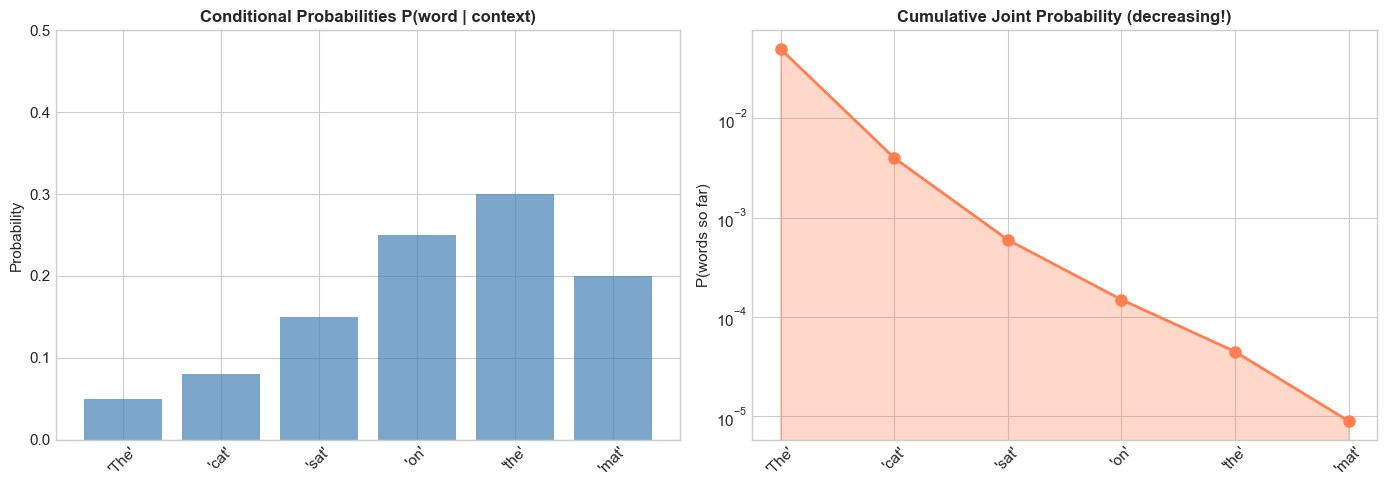


💡 Key Insight:
   • GPT and other language models use exactly this chain rule!
   • They learn P(next_word | all_previous_words)
   • The joint probability gets VERY small for long sequences
   • That's why we use LOG probabilities (turn products into sums)


In [7]:
# 🔗 The Chain Rule - Foundation of Language Models (GPT!)

# Language models compute P(sentence) using the chain rule:
# P(w1, w2, w3, ..., wn) = P(w1) × P(w2|w1) × P(w3|w1,w2) × ... × P(wn|w1,...,wn-1)

# Let's simulate this with a simple sentence
sentence = ["The", "cat", "sat", "on", "the", "mat"]

# Simulated conditional probabilities (in a real LLM, these come from the model)
conditional_probs = [
    0.05,   # P("The")              - common starter
    0.08,   # P("cat" | "The")       - "The cat" is common
    0.15,   # P("sat" | "The cat")   - makes sense
    0.25,   # P("on" | "The cat sat") - very likely
    0.30,   # P("the" | "... sat on") - expected
    0.20,   # P("mat" | "... on the") - reasonable
]

# Calculate joint probability using chain rule
joint_prob = 1.0
cumulative_probs = []

print("🔗 Chain Rule for Language Modeling")
print("=" * 60)
print("\nSentence: 'The cat sat on the mat'")
print("\nBreaking down P(sentence) using the chain rule:\n")

for i, (word, prob) in enumerate(zip(sentence, conditional_probs)):
    context = " ".join(sentence[:i]) if i > 0 else "⟨start⟩"
    print(f"  P('{word}' | '{context}') = {prob:.2f}")
    joint_prob *= prob
    cumulative_probs.append(joint_prob)

print(f"\n{'─' * 60}")
print(f"  P(sentence) = {conditional_probs[0]:.2f}", end="")
for p in conditional_probs[1:]:
    print(f" × {p:.2f}", end="")
print(f" = {joint_prob:.8f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conditional probabilities
ax = axes[0]
x_pos = range(len(sentence))
bars = ax.bar(x_pos, conditional_probs, color='steelblue', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"'{w}'" for w in sentence], rotation=45)
ax.set_title('Conditional Probabilities P(word | context)', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(0, 0.5)

# Cumulative (joint) probability
ax = axes[1]
ax.plot(x_pos, cumulative_probs, 'o-', color='coral', linewidth=2, markersize=8)
ax.fill_between(x_pos, cumulative_probs, alpha=0.3, color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"'{w}'" for w in sentence], rotation=45)
ax.set_title('Cumulative Joint Probability (decreasing!)', fontsize=12, fontweight='bold')
ax.set_ylabel('P(words so far)')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print("   • GPT and other language models use exactly this chain rule!")
print("   • They learn P(next_word | all_previous_words)")
print("   • The joint probability gets VERY small for long sequences")
print("   • That's why we use LOG probabilities (turn products into sums)")

---
# Part 4: Probability Distributions 📊

## The Shapes of Randomness

A probability distribution describes how likely different values are. Here are the ones you'll see constantly in deep learning!

```
┌────────────────────────────────────────────────────────────────┐
│            PROBABILITY DISTRIBUTIONS IN DEEP LEARNING           │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  CONTINUOUS DISTRIBUTIONS (for real-valued data)               │
│  ════════════════════════════════════════════                  │
│                                                                 │
│  1. NORMAL (Gaussian) 𝒩(μ, σ²)                                 │
│     • The "bell curve"                                         │
│     • Used in: Weight initialization, noise, priors            │
│     • PDF: p(x) = (1/√(2πσ²)) exp(-(x-μ)²/(2σ²))              │
│                                                                 │
│  2. UNIFORM U(a, b)                                            │
│     • Equal probability for all values in range                │
│     • Used in: Random initialization, sampling timesteps       │
│                                                                 │
│                                                                 │
│  DISCRETE DISTRIBUTIONS (for categories/counts)                │
│  ═════════════════════════════════════════════                 │
│                                                                 │
│  3. BERNOULLI Ber(p)                                           │
│     • Binary: success (1) or failure (0)                       │
│     • Used in: Dropout! (keep neuron with prob p)              │
│                                                                 │
│  4. CATEGORICAL Cat(p₁, p₂, ..., pₖ)                           │
│     • Generalizes Bernoulli to K categories                    │
│     • Used in: Classification output, token sampling           │
│                                                                 │
│  5. MULTINOMIAL                                                 │
│     • Multiple draws from Categorical                          │
│     • Used in: Batch sampling, data augmentation               │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

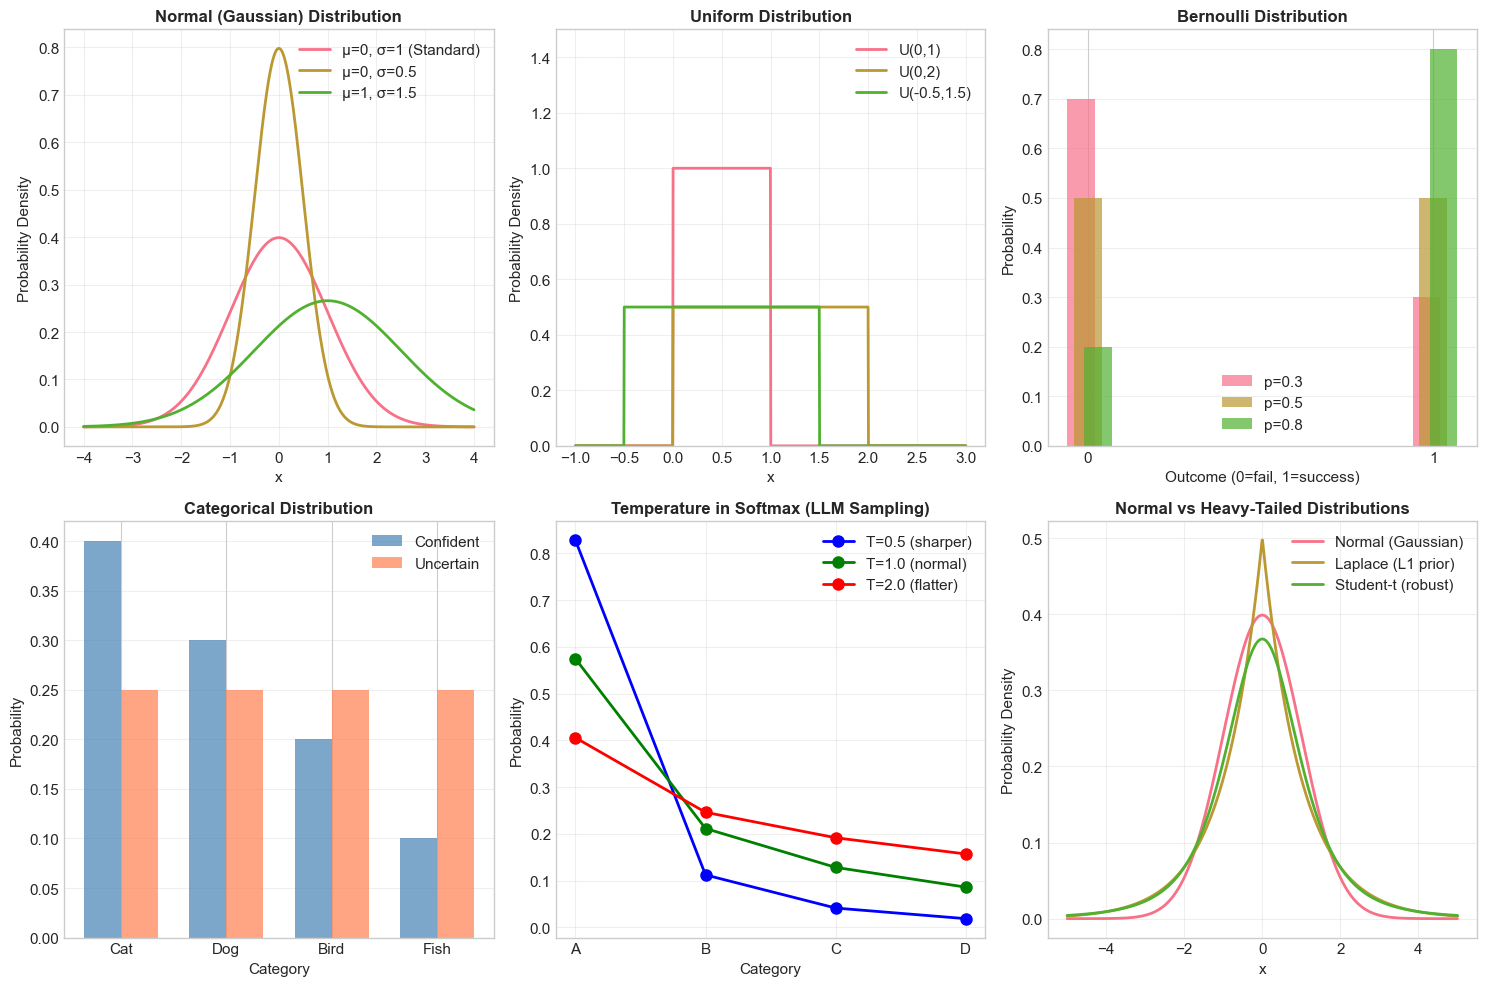

💡 Key Deep Learning Connections:
   • Normal: Weight initialization, VAE latent space, diffusion noise
   • Uniform: Random sampling, positional encodings, hyperparameters
   • Bernoulli: Dropout (p=0.5 means 50% chance to keep neuron)
   • Categorical: Classification output (after softmax)
   • Temperature: Controls 'creativity' in LLM sampling


In [8]:
# 📊 Visualizing Common Distributions

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Normal (Gaussian) Distribution
ax = axes[0, 0]
x = np.linspace(-4, 4, 1000)
for mu, sigma, label in [(0, 1, 'μ=0, σ=1 (Standard)'), (0, 0.5, 'μ=0, σ=0.5'), (1, 1.5, 'μ=1, σ=1.5')]:
    y = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, y, linewidth=2, label=label)
ax.set_title('Normal (Gaussian) Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Uniform Distribution
ax = axes[0, 1]
x = np.linspace(-1, 3, 1000)
for a, b, label in [(0, 1, 'U(0,1)'), (0, 2, 'U(0,2)'), (-0.5, 1.5, 'U(-0.5,1.5)')]:
    y = stats.uniform.pdf(x, a, b-a)
    ax.plot(x, y, linewidth=2, label=label)
ax.set_title('Uniform Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)

# 3. Bernoulli Distribution
ax = axes[0, 2]
for p, color in [(0.3, 'steelblue'), (0.5, 'coral'), (0.8, 'forestgreen')]:
    x_vals = [0, 1]
    probs = [1-p, p]
    offset = (p - 0.5) * 0.1
    ax.bar([x + offset for x in x_vals], probs, width=0.08, label=f'p={p}', alpha=0.7)
ax.set_title('Bernoulli Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Outcome (0=fail, 1=success)')
ax.set_ylabel('Probability')
ax.set_xticks([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Categorical Distribution
ax = axes[1, 0]
categories = ['Cat', 'Dog', 'Bird', 'Fish']
probs1 = [0.4, 0.3, 0.2, 0.1]
probs2 = [0.25, 0.25, 0.25, 0.25]
x_pos = np.arange(len(categories))
width = 0.35
ax.bar(x_pos - width/2, probs1, width, label='Confident', alpha=0.7, color='steelblue')
ax.bar(x_pos + width/2, probs2, width, label='Uncertain', alpha=0.7, color='coral')
ax.set_title('Categorical Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Probability')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 5. Effect of temperature on softmax (important for LLMs!)
ax = axes[1, 1]
logits = np.array([2.0, 1.0, 0.5, 0.1])
categories = ['A', 'B', 'C', 'D']

for temp, color, label in [(0.5, 'blue', 'T=0.5 (sharper)'),
                            (1.0, 'green', 'T=1.0 (normal)'),
                            (2.0, 'red', 'T=2.0 (flatter)')]:
    probs = softmax(logits / temp)
    ax.plot(categories, probs, 'o-', color=color, linewidth=2, markersize=8, label=label)

ax.set_title('Temperature in Softmax (LLM Sampling)', fontsize=12, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Normal vs Heavy-tailed
ax = axes[1, 2]
x = np.linspace(-5, 5, 1000)
normal = stats.norm.pdf(x, 0, 1)
laplace = stats.laplace.pdf(x, 0, 1)
t_dist = stats.t.pdf(x, df=3)

ax.plot(x, normal, linewidth=2, label='Normal (Gaussian)')
ax.plot(x, laplace, linewidth=2, label='Laplace (L1 prior)')
ax.plot(x, t_dist, linewidth=2, label='Student-t (robust)')
ax.set_title('Normal vs Heavy-Tailed Distributions', fontsize=12, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Key Deep Learning Connections:")
print("   • Normal: Weight initialization, VAE latent space, diffusion noise")
print("   • Uniform: Random sampling, positional encodings, hyperparameters")
print("   • Bernoulli: Dropout (p=0.5 means 50% chance to keep neuron)")
print("   • Categorical: Classification output (after softmax)")
print("   • Temperature: Controls 'creativity' in LLM sampling")

🎯 Weight Initialization: Why It Matters


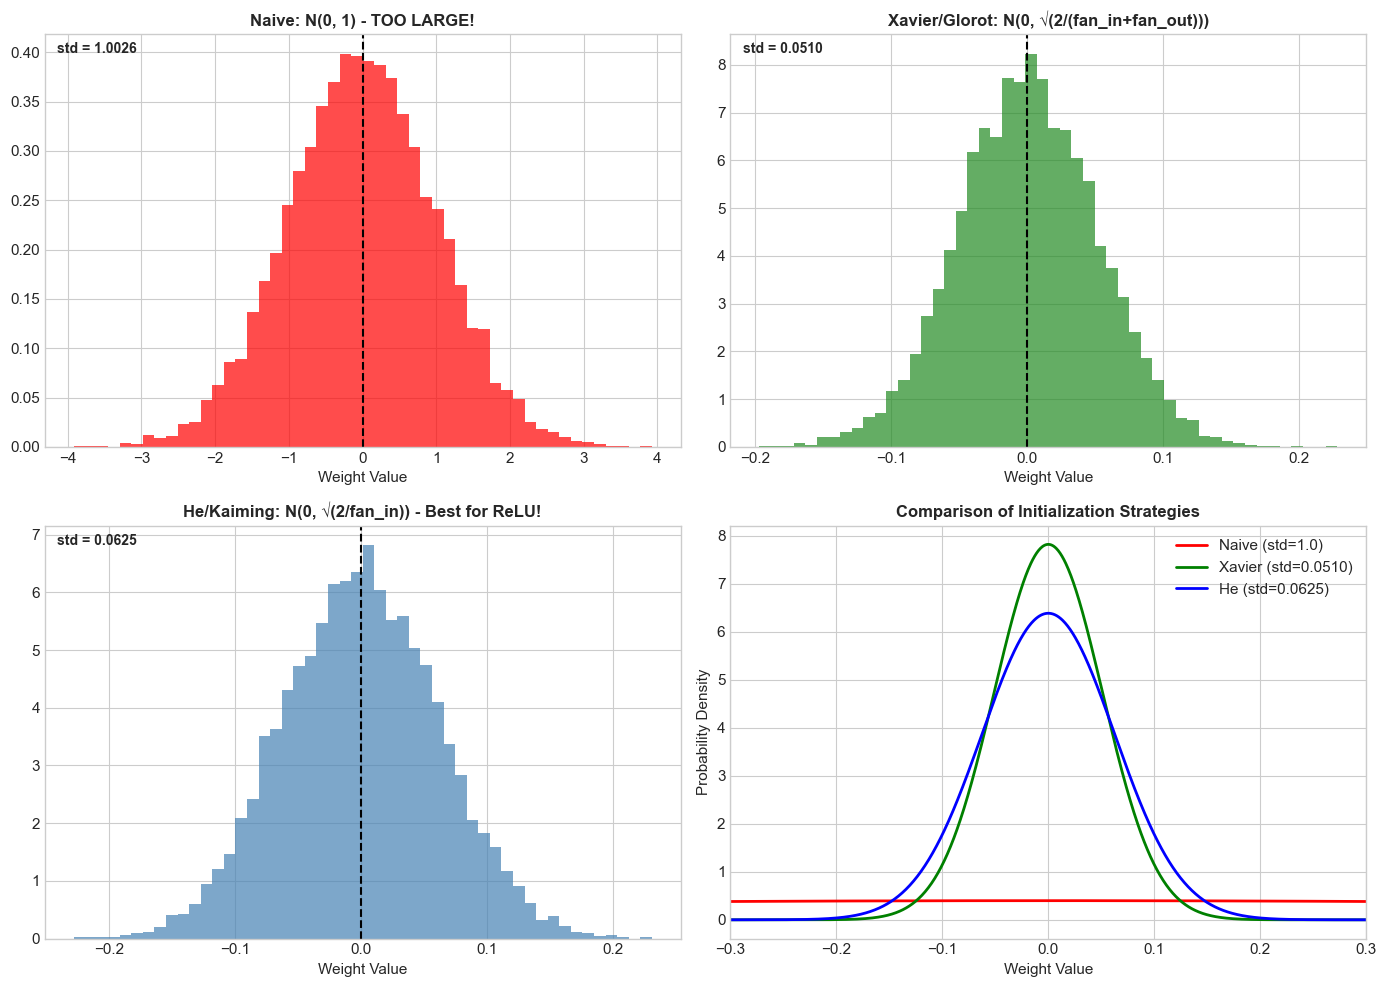


📊 Initialization Formulas:
   • Xavier/Glorot: std = √(2/(fan_in + fan_out)) = √(2/768) = 0.0510
   • He/Kaiming:    std = √(2/fan_in) = √(2/512) = 0.0625

💡 Why This Matters:
   • Too large weights → activations explode → gradients explode
   • Too small weights → activations vanish → gradients vanish
   • Proper init → stable training from the start!

🔧 PyTorch Usage:
   • nn.init.xavier_normal_(layer.weight)  # For tanh/sigmoid
   • nn.init.kaiming_normal_(layer.weight)  # For ReLU (default)


In [9]:
# 🧠 Deep Learning Connection: Weight Initialization
# The distribution we use to initialize weights MATTERS!

def visualize_weight_init():
    """Compare different weight initialization strategies."""

    fan_in = 512   # Number of input neurons
    fan_out = 256  # Number of output neurons
    n_samples = 10000

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Random Normal (naive - BAD!)
    ax = axes[0, 0]
    weights_naive = np.random.normal(0, 1, n_samples)
    ax.hist(weights_naive, bins=50, density=True, alpha=0.7, color='red')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'Naive: N(0, 1) - TOO LARGE!', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.text(0.02, 0.98, f'std = {weights_naive.std():.4f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', fontweight='bold')

    # 2. Xavier/Glorot Initialization (for tanh/sigmoid)
    ax = axes[0, 1]
    xavier_std = np.sqrt(2.0 / (fan_in + fan_out))
    weights_xavier = np.random.normal(0, xavier_std, n_samples)
    ax.hist(weights_xavier, bins=50, density=True, alpha=0.7, color='forestgreen')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'Xavier/Glorot: N(0, √(2/(fan_in+fan_out)))', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.text(0.02, 0.98, f'std = {xavier_std:.4f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', fontweight='bold')

    # 3. He/Kaiming Initialization (for ReLU)
    ax = axes[1, 0]
    he_std = np.sqrt(2.0 / fan_in)
    weights_he = np.random.normal(0, he_std, n_samples)
    ax.hist(weights_he, bins=50, density=True, alpha=0.7, color='steelblue')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'He/Kaiming: N(0, √(2/fan_in)) - Best for ReLU!', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.text(0.02, 0.98, f'std = {he_std:.4f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', fontweight='bold')

    # 4. Comparison overlay
    ax = axes[1, 1]
    x = np.linspace(-0.3, 0.3, 1000)
    ax.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label=f'Naive (std=1.0)')
    ax.plot(x, stats.norm.pdf(x, 0, xavier_std), 'g-', linewidth=2, label=f'Xavier (std={xavier_std:.4f})')
    ax.plot(x, stats.norm.pdf(x, 0, he_std), 'b-', linewidth=2, label=f'He (std={he_std:.4f})')
    ax.set_title('Comparison of Initialization Strategies', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Probability Density')
    ax.legend()
    ax.set_xlim(-0.3, 0.3)

    plt.tight_layout()
    plt.show()

    return xavier_std, he_std


print("🎯 Weight Initialization: Why It Matters")
print("=" * 60)
xavier_std, he_std = visualize_weight_init()

print("\n📊 Initialization Formulas:")
print(f"   • Xavier/Glorot: std = √(2/(fan_in + fan_out)) = √(2/768) = {xavier_std:.4f}")
print(f"   • He/Kaiming:    std = √(2/fan_in) = √(2/512) = {he_std:.4f}")

print("\n💡 Why This Matters:")
print("   • Too large weights → activations explode → gradients explode")
print("   • Too small weights → activations vanish → gradients vanish")
print("   • Proper init → stable training from the start!")

print("\n🔧 PyTorch Usage:")
print("   • nn.init.xavier_normal_(layer.weight)  # For tanh/sigmoid")
print("   • nn.init.kaiming_normal_(layer.weight)  # For ReLU (default)")

---
# Part 5: Expectation and Variance 📐

## The Language of Averages

**Expectation (Expected Value)** is the theoretical average - what we'd get if we sampled infinitely many times.

```
┌────────────────────────────────────────────────────────────────┐
│                    EXPECTATION (E[X])                           │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Discrete:   E[X] = Σ x · P(X = x)                             │
│                                                                 │
│  Continuous: E[X] = ∫ x · p(x) dx                              │
│                                                                 │
│  Example: Fair die roll                                         │
│  E[X] = 1·(1/6) + 2·(1/6) + 3·(1/6) + 4·(1/6) + 5·(1/6) + 6·(1/6)│
│       = 21/6 = 3.5                                             │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  DEEP LEARNING CONNECTIONS:                                     │
│                                                                 │
│  1. LOSS FUNCTION is an expectation!                           │
│     L = E_{(x,y)~data} [ loss(model(x), y) ]                   │
│                                                                 │
│  2. SGD approximates this expectation with mini-batches:       │
│     L ≈ (1/batch_size) Σ loss(model(xᵢ), yᵢ)                  │
│                                                                 │
│  3. Dropout at test time uses expectation:                      │
│     E[output] = p · full_output  (scales by keep probability)  │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## Variance: Measuring Uncertainty

```
┌────────────────────────────────────────────────────────────────┐
│                    VARIANCE (Var[X])                            │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Var[X] = E[(X - E[X])²] = E[X²] - (E[X])²                     │
│                                                                 │
│  "Expected squared distance from the mean"                      │
│                                                                 │
│  DEEP LEARNING CONNECTIONS:                                     │
│                                                                 │
│  1. GRADIENT VARIANCE affects training:                         │
│     • High variance → unstable training                        │
│     • Low variance → stable but slow                           │
│     • SGD trades off: larger batch = lower variance            │
│                                                                 │
│  2. VARIANCE REDUCTION techniques:                              │
│     • Batch normalization                                      │
│     • Learning rate warmup                                     │
│     • Gradient clipping                                        │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

🎲 Die Roll Statistics
E[X] = Σ x·P(x) = 3.50
Var[X] = E[(X-μ)²] = 2.9167
Std[X] = √Var = 1.7078

📊 Empirical (from 10000 simulated rolls):
Sample mean = 3.4999 (theory: 3.50)
Sample var  = 2.9194 (theory: 2.9167)

🧠 Deep Learning Connection: Batch Size Affects Gradient Variance


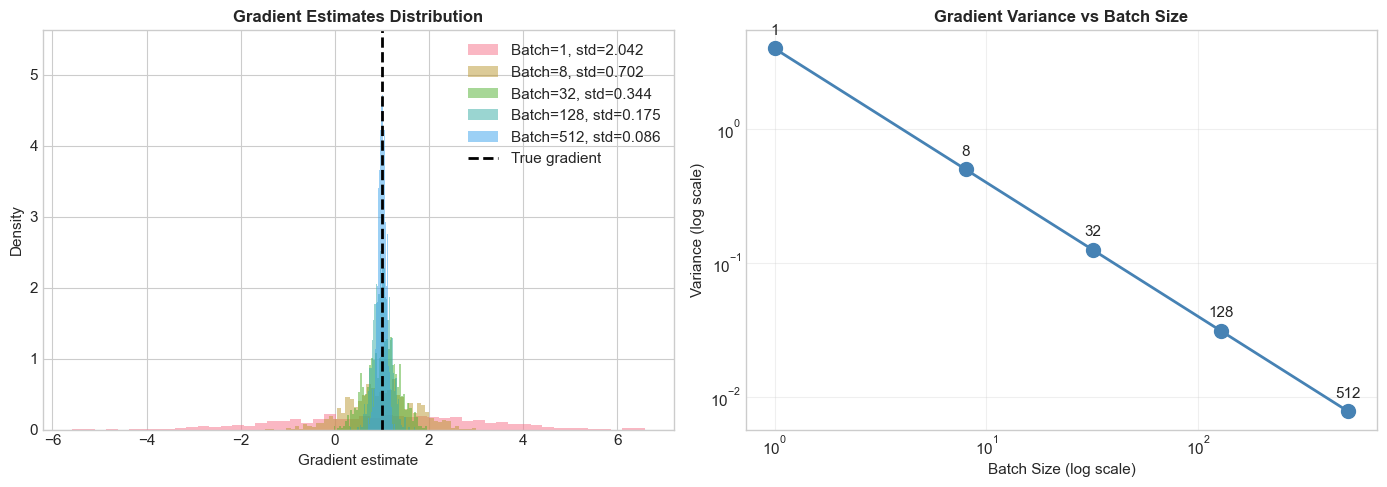


💡 Key Insight: Var[batch_gradient] = Var[single_gradient] / batch_size
   • Larger batch = lower variance = smoother training
   • Smaller batch = higher variance = more noise (but can help escape local minima!)


In [10]:
# 📐 Expectation and Variance - Interactive Demo

# 1. Simple die roll example
die_outcomes = np.array([1, 2, 3, 4, 5, 6])
die_probs = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

# Expected value (theoretical)
expected_value = np.sum(die_outcomes * die_probs)

# Variance
variance_theory = np.sum(die_probs * (die_outcomes - expected_value)**2)

print("🎲 Die Roll Statistics")
print("=" * 50)
print(f"E[X] = Σ x·P(x) = {expected_value:.2f}")
print(f"Var[X] = E[(X-μ)²] = {variance_theory:.4f}")
print(f"Std[X] = √Var = {np.sqrt(variance_theory):.4f}")

# 2. Simulate and compare with empirical values
np.random.seed(42)
n_rolls = 10000
rolls = np.random.randint(1, 7, n_rolls)

print(f"\n📊 Empirical (from {n_rolls} simulated rolls):")
print(f"Sample mean = {rolls.mean():.4f} (theory: {expected_value:.2f})")
print(f"Sample var  = {rolls.var():.4f} (theory: {variance_theory:.4f})")

# 3. Deep Learning Connection: Batch Size and Variance
print("\n" + "=" * 60)
print("🧠 Deep Learning Connection: Batch Size Affects Gradient Variance")
print("=" * 60)

# Simulate gradient estimates with different batch sizes
true_gradient = 1.0
noise_std = 2.0
batch_sizes = [1, 8, 32, 128, 512]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution of gradient estimates for different batch sizes
ax = axes[0]
for batch_size in batch_sizes:
    # Each gradient estimate is an average of noisy observations
    n_estimates = 1000
    gradient_estimates = []
    for _ in range(n_estimates):
        # Sample gradients (true + noise)
        noisy_grads = true_gradient + np.random.normal(0, noise_std, batch_size)
        # Average them (mini-batch gradient)
        gradient_estimates.append(np.mean(noisy_grads))

    gradient_estimates = np.array(gradient_estimates)
    ax.hist(gradient_estimates, bins=50, alpha=0.5, density=True,
            label=f'Batch={batch_size}, std={gradient_estimates.std():.3f}')

ax.axvline(true_gradient, color='black', linestyle='--', linewidth=2, label='True gradient')
ax.set_title('Gradient Estimates Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Gradient estimate')
ax.set_ylabel('Density')
ax.legend()

# Right: Variance vs Batch Size
ax = axes[1]
variances = []
for batch_size in batch_sizes:
    # Variance of mean decreases as O(1/batch_size)
    theoretical_var = (noise_std ** 2) / batch_size
    variances.append(theoretical_var)

ax.loglog(batch_sizes, variances, 'o-', markersize=10, linewidth=2, color='steelblue')
ax.set_title('Gradient Variance vs Batch Size', fontsize=12, fontweight='bold')
ax.set_xlabel('Batch Size (log scale)')
ax.set_ylabel('Variance (log scale)')
ax.grid(True, alpha=0.3)

# Add annotations
for bs, var in zip(batch_sizes, variances):
    ax.annotate(f'{bs}', (bs, var), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Var[batch_gradient] = Var[single_gradient] / batch_size")
print("   • Larger batch = lower variance = smoother training")
print("   • Smaller batch = higher variance = more noise (but can help escape local minima!)")

---
# Part 6: Bayes' Theorem 🎯

## The Foundation of Probabilistic Reasoning

Bayes' theorem tells us how to update our beliefs when we see new evidence.

```
┌────────────────────────────────────────────────────────────────┐
│                     BAYES' THEOREM                              │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│                    P(A|B) · P(B)                                │
│       P(B|A) = ─────────────────                               │
│                      P(A)                                       │
│                                                                 │
│  Or in ML-friendly notation:                                    │
│                                                                 │
│                    P(data|θ) · P(θ)                            │
│       P(θ|data) = ──────────────────                           │
│                      P(data)                                    │
│                                                                 │
│  Where:                                                         │
│  • P(θ|data) = POSTERIOR - what we want (belief after data)   │
│  • P(data|θ) = LIKELIHOOD - how likely is data given model    │
│  • P(θ)      = PRIOR - our initial belief about model         │
│  • P(data)   = EVIDENCE - normalizing constant                 │
│                                                                 │
│                                                                 │
│      POSTERIOR ∝ LIKELIHOOD × PRIOR                            │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## Deep Learning Connections

```
┌────────────────────────────────────────────────────────────────┐
│              BAYES IN DEEP LEARNING                             │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  1. REGULARIZATION = Adding a Prior!                            │
│     • L2 regularization = Gaussian prior on weights            │
│     • L1 regularization = Laplace prior on weights             │
│     • Dropout ≈ Approximate Bayesian inference                 │
│                                                                 │
│  2. UNCERTAINTY ESTIMATION                                      │
│     • Bayesian Neural Networks maintain weight distributions   │
│     • Monte Carlo Dropout estimates uncertainty                │
│                                                                 │
│  3. MAXIMUM A POSTERIORI (MAP) = MLE + Regularization          │
│     θ_MAP = argmax P(θ|data) = argmax [P(data|θ) · P(θ)]      │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

🏥 Medical Test Example - Bayes' Theorem

Prior probability of disease: P(D) = 1.0%
Test accuracy (true positive): P(+|D) = 95.0%
False positive rate: P(+|healthy) = 5.0%

Total probability of positive: P(+) = 0.0590

🎯 POSTERIOR: P(disease | positive) = 16.1%

⚠️ Surprise! Even with a positive test, only ~16% chance of disease!
   This is because the disease is rare (base rate fallacy)


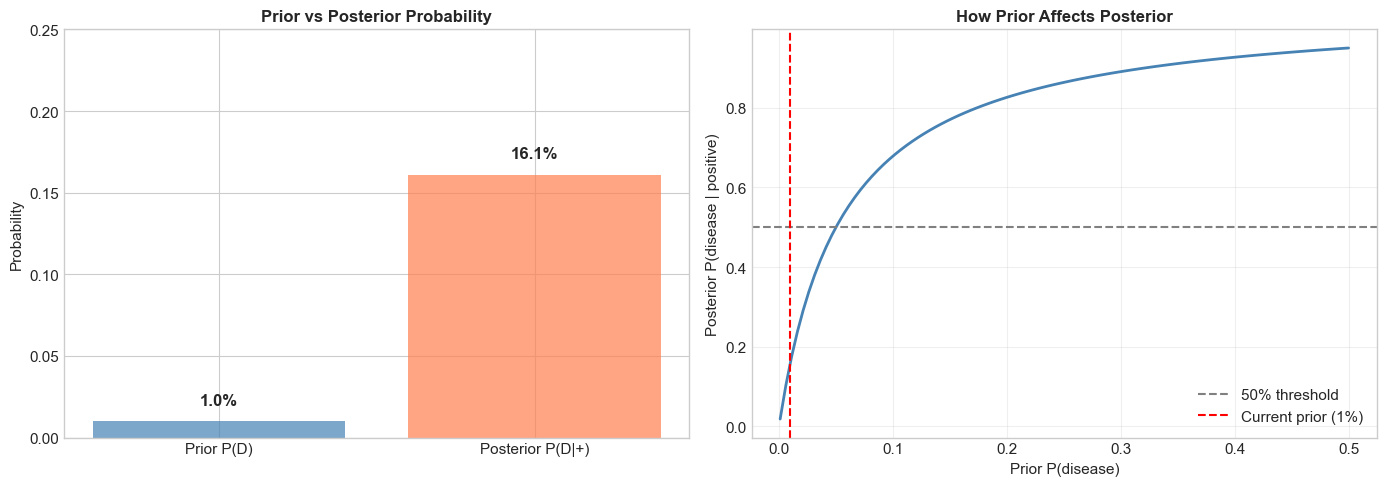


💡 Deep Learning Connection:
   • Prior = Regularization (our belief about good weights)
   • Likelihood = Training loss (how well model fits data)
   • Posterior = Regularized solution (balance fit vs simplicity)


In [11]:
# 🎯 Bayes' Theorem - Visual Demo

# Classic example: Medical test
# Disease affects 1% of population
# Test is 95% accurate (true positive rate)
# False positive rate is 5%

P_disease = 0.01           # Prior: P(disease)
P_positive_given_disease = 0.95  # Likelihood: P(positive | disease)
P_positive_given_healthy = 0.05  # P(positive | healthy)

# Total probability of positive test
P_positive = P_positive_given_disease * P_disease + P_positive_given_healthy * (1 - P_disease)

# Bayes' theorem: P(disease | positive)
P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print("🏥 Medical Test Example - Bayes' Theorem")
print("=" * 60)
print(f"\nPrior probability of disease: P(D) = {P_disease:.1%}")
print(f"Test accuracy (true positive): P(+|D) = {P_positive_given_disease:.1%}")
print(f"False positive rate: P(+|healthy) = {P_positive_given_healthy:.1%}")
print(f"\nTotal probability of positive: P(+) = {P_positive:.4f}")
print(f"\n🎯 POSTERIOR: P(disease | positive) = {P_disease_given_positive:.1%}")
print("\n⚠️ Surprise! Even with a positive test, only ~16% chance of disease!")
print("   This is because the disease is rare (base rate fallacy)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Prior vs Posterior
ax = axes[0]
categories = ['Prior P(D)', 'Posterior P(D|+)']
probs = [P_disease, P_disease_given_positive]
colors = ['steelblue', 'coral']
bars = ax.bar(categories, probs, color=colors, alpha=0.7)
ax.set_ylabel('Probability')
ax.set_title('Prior vs Posterior Probability', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.25)
for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{prob:.1%}', ha='center', fontsize=12, fontweight='bold')

# Right: How prior affects posterior
ax = axes[1]
prior_range = np.linspace(0.001, 0.5, 100)
posteriors = (P_positive_given_disease * prior_range) / (
    P_positive_given_disease * prior_range + P_positive_given_healthy * (1 - prior_range)
)
ax.plot(prior_range, posteriors, linewidth=2, color='steelblue')
ax.axhline(y=0.5, color='gray', linestyle='--', label='50% threshold')
ax.axvline(x=P_disease, color='red', linestyle='--', label=f'Current prior ({P_disease:.0%})')
ax.set_xlabel('Prior P(disease)')
ax.set_ylabel('Posterior P(disease | positive)')
ax.set_title('How Prior Affects Posterior', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Deep Learning Connection:")
print("   • Prior = Regularization (our belief about good weights)")
print("   • Likelihood = Training loss (how well model fits data)")
print("   • Posterior = Regularized solution (balance fit vs simplicity)")

---
# Part 7: Maximum Likelihood Estimation (MLE) 📈

## The Heart of Training Neural Networks!

**MLE** finds the model parameters that make the observed data most likely.

```
┌────────────────────────────────────────────────────────────────┐
│              MAXIMUM LIKELIHOOD ESTIMATION                      │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Goal: Find θ that maximizes P(data | θ)                       │
│                                                                 │
│  θ_MLE = argmax P(x₁, x₂, ..., xₙ | θ)                         │
│                θ                                                │
│                                                                 │
│  For independent samples:                                       │
│  P(data | θ) = ∏ P(xᵢ | θ)                                     │
│                 i                                               │
│                                                                 │
│  Taking log (since log is monotonic):                          │
│  log P(data | θ) = Σ log P(xᵢ | θ)                             │
│                     i                                           │
│                                                                 │
│  ┌─────────────────────────────────────────────────────────┐   │
│  │                                                          │   │
│  │   MAXIMIZING log-likelihood = MINIMIZING negative LL    │   │
│  │                                                          │   │
│  │   This is EXACTLY what loss functions do!               │   │
│  │                                                          │   │
│  └─────────────────────────────────────────────────────────┘   │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## The Deep Learning Connection: Training IS MLE!

| Statistical View | Deep Learning View |
|-----------------|-------------------|
| Likelihood P(data\|θ) | Model probability of correct labels |
| Log-likelihood | Negative loss function |
| Maximize likelihood | Minimize loss |
| MLE parameters | Trained weights |

📈 Cross-Entropy Loss = Negative Log-Likelihood

True label: Class 1 (one-hot: [0 1 0])

Different predictions and their losses:

  Confident & Correct:
    Prediction: [0.05 0.9  0.05]
    P(true class) = 0.90
    Cross-entropy = -log(0.90) = 0.1054
    Log-likelihood = -0.1054

  Correct but Uncertain:
    Prediction: [0.2 0.5 0.3]
    P(true class) = 0.50
    Cross-entropy = -log(0.50) = 0.6931
    Log-likelihood = -0.6931

  Wrong Prediction:
    Prediction: [0.7 0.2 0.1]
    P(true class) = 0.20
    Cross-entropy = -log(0.20) = 1.6094
    Log-likelihood = -1.6094

  Very Wrong:
    Prediction: [0.9  0.05 0.05]
    P(true class) = 0.05
    Cross-entropy = -log(0.05) = 2.9957
    Log-likelihood = -2.9957



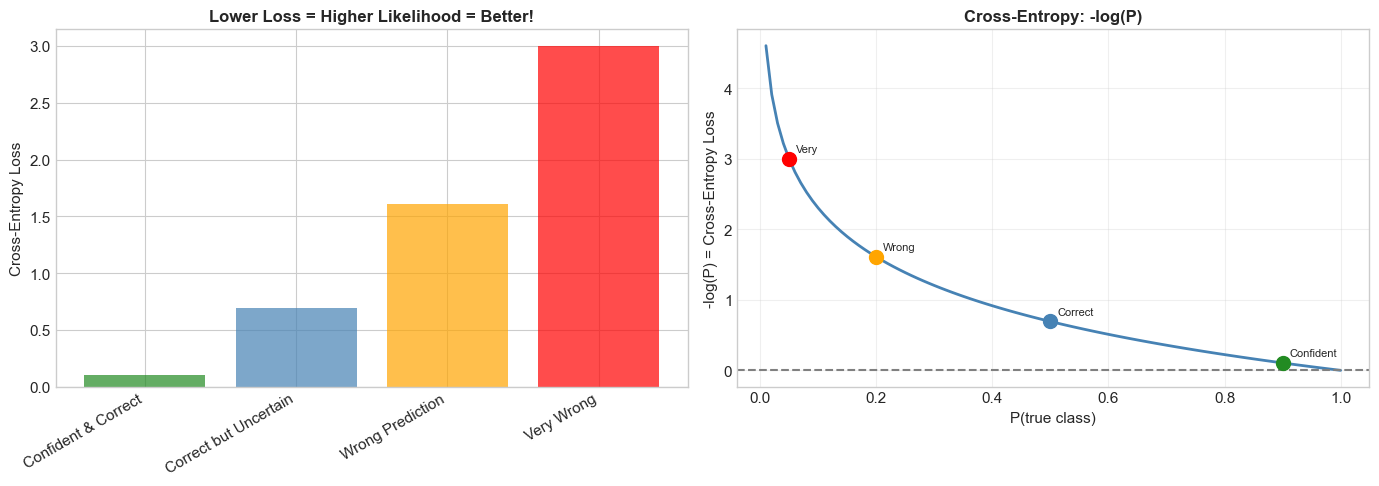

💡 Key Insight:
   • When P(true class) → 1: loss → 0 (perfect!)
   • When P(true class) → 0: loss → ∞ (terrible!)
   • Minimizing cross-entropy = Maximizing likelihood!


In [12]:
# 📈 MLE in Action - Training is Maximum Likelihood!

# Let's show that cross-entropy loss = negative log-likelihood

def cross_entropy_loss(y_true, y_pred):
    """
    Cross-entropy loss for classification.

    This is EXACTLY the negative log-likelihood!

    H(p, q) = -Σ p(x) log q(x)

    For one-hot targets: -log(predicted_prob_of_true_class)
    """
    # Clip to avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1.0)
    return -np.sum(y_true * np.log(y_pred))


# Example: 3-class classification
true_labels = np.array([0, 1, 0])  # One-hot: class 1 is correct

# Different model predictions
predictions = {
    'Confident & Correct': np.array([0.05, 0.90, 0.05]),
    'Correct but Uncertain': np.array([0.2, 0.5, 0.3]),
    'Wrong Prediction': np.array([0.7, 0.2, 0.1]),
    'Very Wrong': np.array([0.9, 0.05, 0.05]),
}

print("📈 Cross-Entropy Loss = Negative Log-Likelihood")
print("=" * 60)
print(f"\nTrue label: Class 1 (one-hot: {true_labels})")
print("\nDifferent predictions and their losses:\n")

losses = []
labels = []
for name, pred in predictions.items():
    loss = cross_entropy_loss(true_labels, pred)
    log_likelihood = -loss
    losses.append(loss)
    labels.append(name)
    print(f"  {name}:")
    print(f"    Prediction: {pred}")
    print(f"    P(true class) = {pred[1]:.2f}")
    print(f"    Cross-entropy = -log({pred[1]:.2f}) = {loss:.4f}")
    print(f"    Log-likelihood = {log_likelihood:.4f}")
    print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss values
ax = axes[0]
colors = ['forestgreen', 'steelblue', 'orange', 'red']
bars = ax.bar(range(len(losses)), losses, color=colors, alpha=0.7)
ax.set_xticks(range(len(losses)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Lower Loss = Higher Likelihood = Better!', fontsize=12, fontweight='bold')

# Right: Log relationship
ax = axes[1]
p = np.linspace(0.01, 1.0, 100)
neg_log_p = -np.log(p)
ax.plot(p, neg_log_p, linewidth=2, color='steelblue')
ax.set_xlabel('P(true class)')
ax.set_ylabel('-log(P) = Cross-Entropy Loss')
ax.set_title('Cross-Entropy: -log(P)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--')

# Mark our examples
for name, pred, color in zip(labels, predictions.values(), colors):
    p_true = pred[1]
    loss = -np.log(p_true)
    ax.scatter([p_true], [loss], color=color, s=100, zorder=5)
    ax.annotate(name.split()[0], (p_true, loss), textcoords="offset points",
                xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

print("💡 Key Insight:")
print("   • When P(true class) → 1: loss → 0 (perfect!)")
print("   • When P(true class) → 0: loss → ∞ (terrible!)")
print("   • Minimizing cross-entropy = Maximizing likelihood!")

---
# Part 8: Information Theory 📡

## Entropy, Cross-Entropy, and KL Divergence

Information theory gives us the mathematical foundation for loss functions!

```
┌────────────────────────────────────────────────────────────────┐
│                    INFORMATION THEORY                           │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ENTROPY H(P) - Uncertainty in a distribution                  │
│  ─────────────────────────────────────────────                 │
│  H(P) = -Σ P(x) log P(x)                                       │
│                                                                 │
│  • High entropy = high uncertainty (uniform distribution)      │
│  • Low entropy = low uncertainty (peaked distribution)         │
│  • Measured in bits (log base 2) or nats (natural log)        │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  CROSS-ENTROPY H(P, Q) - Encoding P using Q                    │
│  ────────────────────────────────────────────                  │
│  H(P, Q) = -Σ P(x) log Q(x)                                    │
│                                                                 │
│  • P = true distribution (data)                                │
│  • Q = predicted distribution (model)                          │
│  • H(P, Q) ≥ H(P), equality when Q = P                        │
│                                                                 │
│  THIS IS YOUR CLASSIFICATION LOSS FUNCTION!                    │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  KL DIVERGENCE D_KL(P || Q) - "Distance" between distributions │
│  ─────────────────────────────────────────────────────────────│
│  D_KL(P || Q) = Σ P(x) log(P(x) / Q(x))                        │
│              = H(P, Q) - H(P)                                  │
│                                                                 │
│  • Always ≥ 0                                                  │
│  • = 0 only when P = Q                                         │
│  • NOT symmetric: D_KL(P||Q) ≠ D_KL(Q||P)                     │
│                                                                 │
│  USED IN: VAEs, Knowledge Distillation, Policy Gradients      │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

📡 Information Theory Concepts

1. ENTROPY - Measure of Uncertainty
----------------------------------------
   Uniform        : H = 1.3863 nats
   Confident      : H = 0.4280 nats
   Very Confident : H = 0.1677 nats

   → Uniform has MAXIMUM entropy (most uncertainty)
   → Confident predictions have LOW entropy


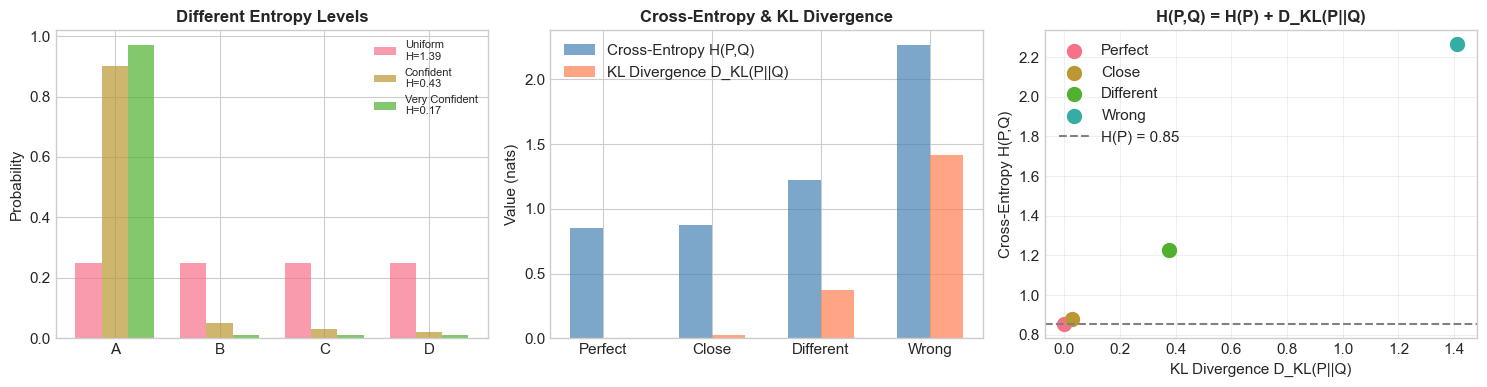


💡 Key Deep Learning Connections:
   • Cross-entropy loss = comparing model Q to true distribution P
   • Minimizing cross-entropy = minimizing KL divergence (since H(P) is fixed)
   • KL divergence used in VAEs to regularize latent space


In [13]:
# 📡 Information Theory - Entropy, Cross-Entropy, KL Divergence

def entropy(p):
    """Calculate entropy H(P) = -Σ P(x) log P(x)"""
    p = np.array(p)
    p = p[p > 0]  # Remove zeros to avoid log(0)
    return -np.sum(p * np.log(p))


def cross_entropy(p, q):
    """Calculate cross-entropy H(P, Q) = -Σ P(x) log Q(x)"""
    p, q = np.array(p), np.array(q)
    q = np.clip(q, 1e-10, 1.0)  # Avoid log(0)
    return -np.sum(p * np.log(q))


def kl_divergence(p, q):
    """Calculate KL divergence D_KL(P || Q) = Σ P(x) log(P(x) / Q(x))"""
    p, q = np.array(p), np.array(q)
    q = np.clip(q, 1e-10, 1.0)
    p = np.clip(p, 1e-10, 1.0)
    return np.sum(p * np.log(p / q))


# Example distributions
distributions = {
    'Uniform': np.array([0.25, 0.25, 0.25, 0.25]),
    'Confident': np.array([0.9, 0.05, 0.03, 0.02]),
    'Very Confident': np.array([0.97, 0.01, 0.01, 0.01]),
}

print("📡 Information Theory Concepts")
print("=" * 60)
print("\n1. ENTROPY - Measure of Uncertainty")
print("-" * 40)
for name, dist in distributions.items():
    H = entropy(dist)
    print(f"   {name:15s}: H = {H:.4f} nats")

print("\n   → Uniform has MAXIMUM entropy (most uncertainty)")
print("   → Confident predictions have LOW entropy")

# Visualize entropy
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Entropy of different distributions
ax = axes[0]
categories = ['A', 'B', 'C', 'D']
width = 0.25
x = np.arange(len(categories))
for i, (name, dist) in enumerate(distributions.items()):
    ax.bar(x + i*width, dist, width, label=f'{name}\nH={entropy(dist):.2f}', alpha=0.7)
ax.set_xticks(x + width)
ax.set_xticklabels(categories)
ax.set_ylabel('Probability')
ax.set_title('Different Entropy Levels', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

# 2. Cross-entropy and KL divergence
ax = axes[1]
P_true = np.array([0.7, 0.2, 0.08, 0.02])  # True distribution

# Various predictions
predictions = [
    ('Perfect', P_true),
    ('Close', np.array([0.6, 0.25, 0.1, 0.05])),
    ('Different', np.array([0.3, 0.3, 0.3, 0.1])),
    ('Wrong', np.array([0.1, 0.1, 0.1, 0.7])),
]

ce_values = []
kl_values = []
labels = []

for name, Q in predictions:
    ce = cross_entropy(P_true, Q)
    kl = kl_divergence(P_true, Q)
    ce_values.append(ce)
    kl_values.append(kl)
    labels.append(name)

x = np.arange(len(labels))
ax.bar(x - 0.15, ce_values, 0.3, label='Cross-Entropy H(P,Q)', alpha=0.7, color='steelblue')
ax.bar(x + 0.15, kl_values, 0.3, label='KL Divergence D_KL(P||Q)', alpha=0.7, color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Value (nats)')
ax.set_title('Cross-Entropy & KL Divergence', fontsize=12, fontweight='bold')
ax.legend()

# 3. Relationship between entropy, cross-entropy, and KL
ax = axes[2]
H_P = entropy(P_true)
for name, Q in predictions:
    ce = cross_entropy(P_true, Q)
    kl = kl_divergence(P_true, Q)
    ax.scatter(kl, ce, s=100, label=f'{name}')

ax.axhline(H_P, color='gray', linestyle='--', label=f'H(P) = {H_P:.2f}')
ax.set_xlabel('KL Divergence D_KL(P||Q)')
ax.set_ylabel('Cross-Entropy H(P,Q)')
ax.set_title('H(P,Q) = H(P) + D_KL(P||Q)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Deep Learning Connections:")
print("   • Cross-entropy loss = comparing model Q to true distribution P")
print("   • Minimizing cross-entropy = minimizing KL divergence (since H(P) is fixed)")
print("   • KL divergence used in VAEs to regularize latent space")

---
# Part 9: Sampling & Monte Carlo Methods 🎲

## The Art of Approximation

When we can't compute expectations exactly, we **sample**!

```
┌────────────────────────────────────────────────────────────────┐
│                   MONTE CARLO ESTIMATION                        │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  True expectation:  E_p[f(x)] = ∫ f(x) p(x) dx                 │
│                                                                 │
│  Monte Carlo:       E_p[f(x)] ≈ (1/N) Σ f(xᵢ)  where xᵢ ~ p   │
│                                                                 │
│  As N → ∞, the approximation becomes exact!                    │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  DEEP LEARNING APPLICATIONS:                                    │
│                                                                 │
│  1. STOCHASTIC GRADIENT DESCENT (SGD)                          │
│     • True gradient = expectation over all data                │
│     • Mini-batch gradient = Monte Carlo estimate               │
│                                                                 │
│  2. DROPOUT (Training)                                          │
│     • Samples random subnetworks                               │
│     • Approximates ensemble of networks                        │
│                                                                 │
│  3. VARIATIONAL AUTOENCODERS (VAE)                             │
│     • Reparameterization trick for sampling z ~ q(z|x)         │
│                                                                 │
│  4. DIFFUSION MODELS                                            │
│     • Sample noise at each timestep                            │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

🎲 Monte Carlo: Estimating π
   N =      10: π ≈ 3.600000, error = 0.458407
   N =     100: π ≈ 3.120000, error = 0.021593
   N =    1000: π ≈ 3.184000, error = 0.042407
   N =   10000: π ≈ 3.128800, error = 0.012793
   N =  100000: π ≈ 3.145840, error = 0.004247
   N = 1000000: π ≈ 3.141720, error = 0.000127


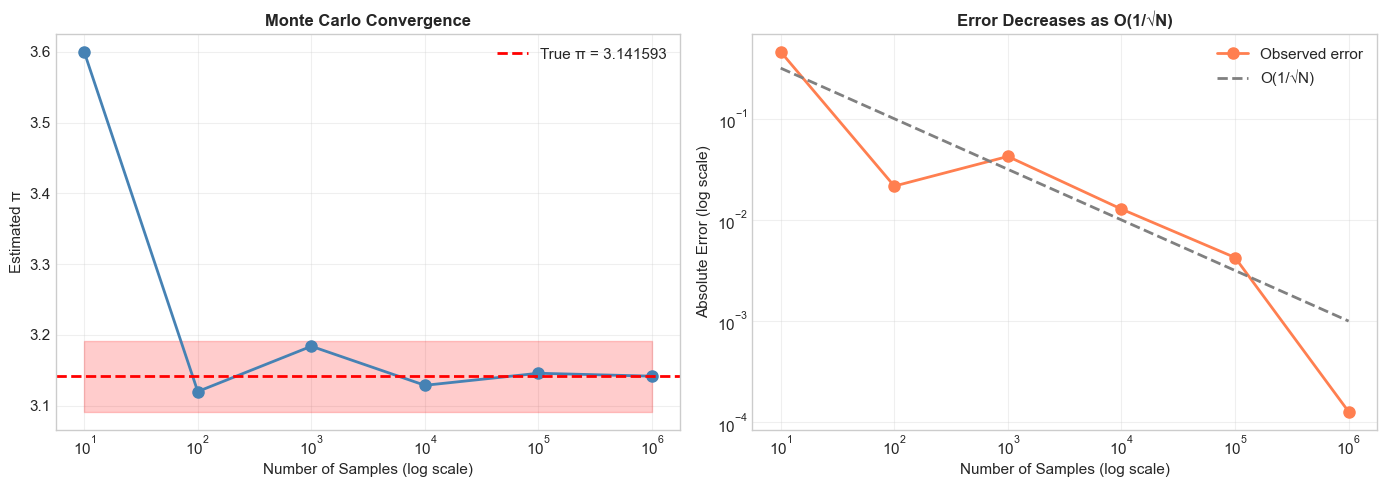


🧠 Dropout as Monte Carlo Sampling

Same input, different outputs due to dropout sampling:
  Forward pass 1: [-2.7990828  2.030345   0.       ]...
  Forward pass 2: [-2.7990828  0.         0.       ]...
  Forward pass 3: [-0.        2.030345  0.      ]...
  Forward pass 4: [-2.7990828  0.         0.       ]...
  Forward pass 5: [-0.         0.         1.9907907]...

💡 Key Insight:
   • Each forward pass samples a different subnetwork
   • At test time, we average (use expected value)
   • This approximates an ensemble of 2^n networks!


In [14]:
# 🎲 Monte Carlo Estimation & Dropout Demo

# 1. Classic example: Estimate π using Monte Carlo
def estimate_pi(n_samples):
    """Estimate π by sampling points in a square and checking if they're in the circle."""
    # Sample points uniformly in [0, 1] x [0, 1]
    x = np.random.uniform(0, 1, n_samples)
    y = np.random.uniform(0, 1, n_samples)

    # Check if inside quarter circle (x² + y² ≤ 1)
    inside = (x**2 + y**2) <= 1

    # Ratio inside × 4 = π
    pi_estimate = 4 * np.mean(inside)
    return pi_estimate


print("🎲 Monte Carlo: Estimating π")
print("=" * 50)

sample_sizes = [10, 100, 1000, 10000, 100000, 1000000]
estimates = []
errors = []

for n in sample_sizes:
    pi_est = estimate_pi(n)
    error = abs(pi_est - np.pi)
    estimates.append(pi_est)
    errors.append(error)
    print(f"   N = {n:>7d}: π ≈ {pi_est:.6f}, error = {error:.6f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Convergence of estimate
ax = axes[0]
ax.semilogx(sample_sizes, estimates, 'o-', markersize=8, linewidth=2, color='steelblue')
ax.axhline(np.pi, color='red', linestyle='--', linewidth=2, label=f'True π = {np.pi:.6f}')
ax.fill_between(sample_sizes, np.pi - 0.05, np.pi + 0.05, alpha=0.2, color='red')
ax.set_xlabel('Number of Samples (log scale)')
ax.set_ylabel('Estimated π')
ax.set_title('Monte Carlo Convergence', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Error decreases as O(1/√N)
ax = axes[1]
ax.loglog(sample_sizes, errors, 'o-', markersize=8, linewidth=2, color='coral', label='Observed error')
theoretical_error = 1 / np.sqrt(np.array(sample_sizes))
ax.loglog(sample_sizes, theoretical_error, '--', linewidth=2, color='gray', label='O(1/√N)')
ax.set_xlabel('Number of Samples (log scale)')
ax.set_ylabel('Absolute Error (log scale)')
ax.set_title('Error Decreases as O(1/√N)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Dropout as Monte Carlo Sampling
print("\n" + "=" * 60)
print("🧠 Dropout as Monte Carlo Sampling")
print("=" * 60)

class DropoutDemo(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.fc = nn.Linear(10, 5)
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        return self.dropout(self.fc(x))


# Show that dropout creates different outputs each forward pass
model = DropoutDemo(p=0.5)
model.train()  # Dropout active

x = torch.randn(1, 10)

print("\nSame input, different outputs due to dropout sampling:")
for i in range(5):
    output = model(x)
    print(f"  Forward pass {i+1}: {output.detach().numpy().flatten()[:3]}...")

print("\n💡 Key Insight:")
print("   • Each forward pass samples a different subnetwork")
print("   • At test time, we average (use expected value)")
print("   • This approximates an ensemble of 2^n networks!")

---
# Part 10: Covariance & Correlation 📈

## Understanding Relationships Between Variables

```
┌────────────────────────────────────────────────────────────────┐
│              COVARIANCE AND CORRELATION                         │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  COVARIANCE: How two variables move together                   │
│  ─────────────────────────────────────────────                 │
│  Cov(X, Y) = E[(X - μ_X)(Y - μ_Y)]                             │
│                                                                 │
│  • Cov > 0: X and Y increase together                          │
│  • Cov < 0: X increases when Y decreases                       │
│  • Cov = 0: No linear relationship                             │
│                                                                 │
│  CORRELATION: Normalized covariance (-1 to 1)                  │
│  ────────────────────────────────────────────                  │
│  ρ(X, Y) = Cov(X, Y) / (σ_X · σ_Y)                             │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  DEEP LEARNING APPLICATIONS:                                    │
│                                                                 │
│  1. FEATURE DECORRELATION                                       │
│     • Batch norm helps decorrelate features                    │
│     • Reduces redundancy in representations                    │
│                                                                 │
│  2. ATTENTION MECHANISMS                                        │
│     • Attention = learned correlation between tokens           │
│     • Q·Kᵀ computes similarity (related to correlation)        │
│                                                                 │
│  3. COVARIANCE MATRIX                                           │
│     • Used in PCA for dimensionality reduction                 │
│     • VAE: models covariance of latent space                   │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

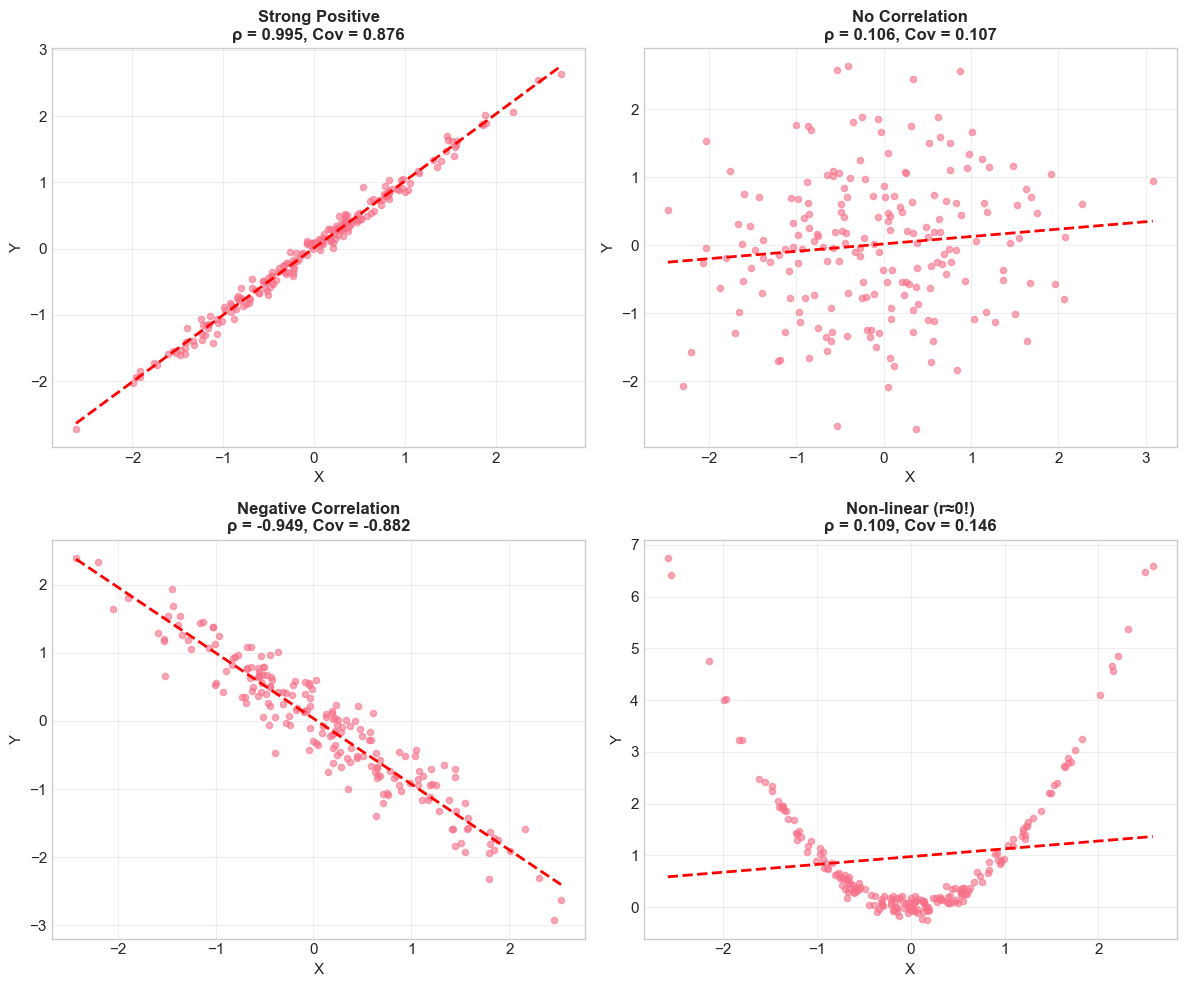

💡 Key Insights:
   • Correlation ρ ranges from -1 to +1
   • ρ = 0 doesn't mean independent! (see non-linear plot)
   • Attention in Transformers computes similarity like correlation


In [15]:
# 📈 Covariance and Correlation Visualization

np.random.seed(42)

# Generate different types of correlations
n = 200

# Perfect positive correlation
x1 = np.random.normal(0, 1, n)
y1 = x1 + np.random.normal(0, 0.1, n)

# No correlation
x2 = np.random.normal(0, 1, n)
y2 = np.random.normal(0, 1, n)

# Negative correlation
x3 = np.random.normal(0, 1, n)
y3 = -x3 + np.random.normal(0, 0.3, n)

# Non-linear relationship (zero correlation but dependent!)
x4 = np.random.normal(0, 1, n)
y4 = x4**2 + np.random.normal(0, 0.1, n)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

datasets = [
    (x1, y1, 'Strong Positive'),
    (x2, y2, 'No Correlation'),
    (x3, y3, 'Negative Correlation'),
    (x4, y4, 'Non-linear (r≈0!)'),
]

for ax, (x, y, title) in zip(axes.flatten(), datasets):
    ax.scatter(x, y, alpha=0.6, s=20)
    corr = np.corrcoef(x, y)[0, 1]
    cov = np.cov(x, y)[0, 1]
    ax.set_title(f'{title}\nρ = {corr:.3f}, Cov = {cov:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)

    # Add regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)

plt.tight_layout()
plt.show()

print("💡 Key Insights:")
print("   • Correlation ρ ranges from -1 to +1")
print("   • ρ = 0 doesn't mean independent! (see non-linear plot)")
print("   • Attention in Transformers computes similarity like correlation")

---
# Part 11: Regularization from a Statistical View 🛡️

## The Bayesian Interpretation of Regularization

Regularization isn't just a trick - it's **Bayesian inference**!

```
┌────────────────────────────────────────────────────────────────┐
│          REGULARIZATION = ADDING A PRIOR                        │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Standard Training (MLE):                                       │
│  θ = argmax log P(data | θ)                                    │
│                                                                 │
│  With Regularization (MAP):                                     │
│  θ = argmax [log P(data | θ) + log P(θ)]                       │
│           = argmax [log P(θ | data)]  ← Posterior!             │
│                                                                 │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  L2 REGULARIZATION = GAUSSIAN PRIOR                            │
│  ────────────────────────────────────                          │
│  Loss = CrossEntropy + λ·||θ||²                                │
│                                                                 │
│  Equivalent to: P(θ) = N(0, 1/(2λ))                            │
│  "Weights should be close to zero"                             │
│                                                                 │
│  L1 REGULARIZATION = LAPLACE PRIOR                             │
│  ────────────────────────────────────                          │
│  Loss = CrossEntropy + λ·||θ||₁                                │
│                                                                 │
│  Equivalent to: P(θ) = Laplace(0, 1/λ)                         │
│  "Weights should be exactly zero" → Sparsity!                  │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97860/3653994880.py:82: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97860/3653994880.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/anitaagasaveeran/Desktop/MSSE_Fall2026/CMPE255/Assignment2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/anitaagasaveeran/Desktop/MSSE_Fall2026/CMPE255/Assignment2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


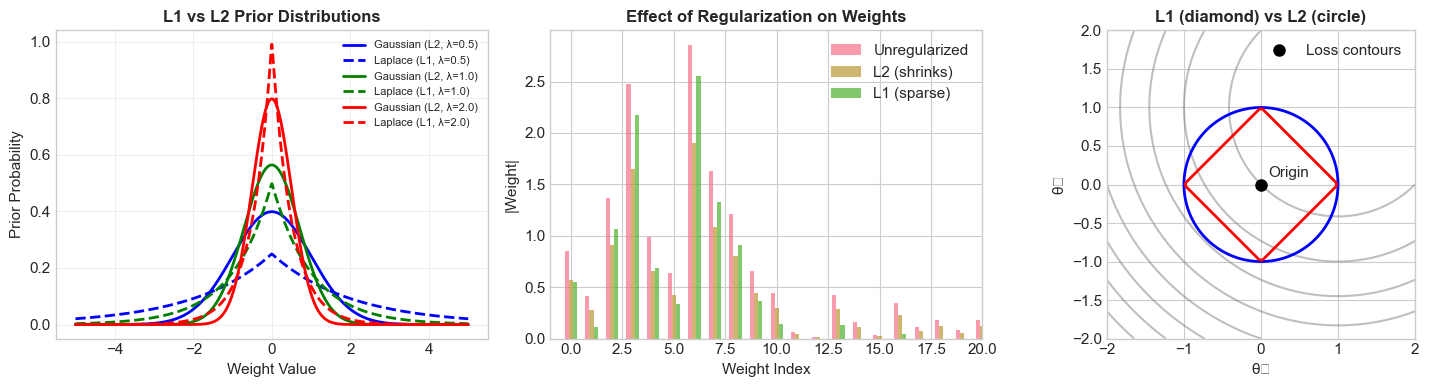

💡 Key Insight:
   • L2 (weight decay): Prefers small weights, smooth solution
   • L1 (lasso): Prefers zero weights, sparse solution
   • The diamond shape of L1 makes solutions hit the axes (zeros)!


In [16]:
# 🛡️ L1 vs L2 Regularization - The Statistical View

# Visualize the prior distributions
x = np.linspace(-5, 5, 1000)

# Gaussian prior (L2) with different λ
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Prior distributions
ax = axes[0]
for lambda_val, color in [(0.5, 'blue'), (1.0, 'green'), (2.0, 'red')]:
    gaussian = stats.norm.pdf(x, 0, 1/np.sqrt(2*lambda_val))
    laplace = stats.laplace.pdf(x, 0, 1/lambda_val)
    ax.plot(x, gaussian, color=color, linestyle='-', linewidth=2,
            label=f'Gaussian (L2, λ={lambda_val})')
    ax.plot(x, laplace, color=color, linestyle='--', linewidth=2,
            label=f'Laplace (L1, λ={lambda_val})')

ax.set_xlabel('Weight Value')
ax.set_ylabel('Prior Probability')
ax.set_title('L1 vs L2 Prior Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Middle: Effect on weights (simulated)
ax = axes[1]

# True signal
n_features = 50
np.random.seed(42)
true_weights = np.zeros(n_features)
true_weights[:10] = np.random.randn(10) * 2  # Only 10 non-zero weights

# Add noise
noisy_weights = true_weights + np.random.randn(n_features) * 0.3

# L2 regularization: shrinks all weights
l2_weights = noisy_weights / (1 + 0.5)

# L1 regularization: sets small weights to zero (soft thresholding)
l1_threshold = 0.3
l1_weights = np.sign(noisy_weights) * np.maximum(np.abs(noisy_weights) - l1_threshold, 0)

x_pos = np.arange(n_features)
ax.bar(x_pos - 0.2, np.abs(noisy_weights), 0.2, label='Unregularized', alpha=0.7)
ax.bar(x_pos, np.abs(l2_weights), 0.2, label='L2 (shrinks)', alpha=0.7)
ax.bar(x_pos + 0.2, np.abs(l1_weights), 0.2, label='L1 (sparse)', alpha=0.7)
ax.set_xlabel('Weight Index')
ax.set_ylabel('|Weight|')
ax.set_title('Effect of Regularization on Weights', fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlim(-1, 20)

# Right: Why L1 creates sparsity
ax = axes[2]

# Contour plot of L1 vs L2 constraints
theta1 = np.linspace(-2, 2, 100)
theta2 = np.linspace(-2, 2, 100)
T1, T2 = np.meshgrid(theta1, theta2)

# Loss contours (ellipse centered away from origin)
loss = 0.5 * ((T1 - 1)**2 + (T2 - 1)**2)

# Constraint regions
l2_constraint = T1**2 + T2**2
l1_constraint = np.abs(T1) + np.abs(T2)

ax.contour(T1, T2, loss, levels=10, colors='gray', alpha=0.5)
ax.contour(T1, T2, l2_constraint, levels=[1], colors='blue', linewidths=2, linestyles='-')
ax.contour(T1, T2, l1_constraint, levels=[1], colors='red', linewidths=2, linestyles='-')

ax.plot([0], [0], 'ko', markersize=8)
ax.annotate('Origin', (0.1, 0.1))

ax.set_xlabel('θ₁')
ax.set_ylabel('θ₂')
ax.set_title('L1 (diamond) vs L2 (circle)', fontsize=12, fontweight='bold')
ax.set_aspect('equal')
ax.legend(['Loss contours', 'L2 constraint', 'L1 constraint'], loc='upper right')

plt.tight_layout()
plt.show()

print("💡 Key Insight:")
print("   • L2 (weight decay): Prefers small weights, smooth solution")
print("   • L1 (lasso): Prefers zero weights, sparse solution")
print("   • The diamond shape of L1 makes solutions hit the axes (zeros)!")

---
# Part 12: Summary & Complete Picture 🎓

## What You've Learned

```
┌────────────────────────────────────────────────────────────────┐
│              STATISTICS FOR DEEP LEARNING - SUMMARY             │
├────────────────────────────────────────────────────────────────┤
│                                                                 │
│  DESCRIPTIVE STATISTICS                                         │
│  ├── Mean, Variance, Std → Batch Normalization                 │
│  └── Data standardization → Stable training                    │
│                                                                 │
│  PROBABILITY                                                    │
│  ├── Softmax → Valid probability distribution                  │
│  ├── Chain rule → Language models (GPT)                        │
│  └── Conditional probability → P(class|input)                  │
│                                                                 │
│  DISTRIBUTIONS                                                  │
│  ├── Normal → Weight initialization, noise                     │
│  ├── Bernoulli → Dropout                                       │
│  └── Categorical → Classification output                       │
│                                                                 │
│  EXPECTATION & VARIANCE                                         │
│  ├── Loss = Expected loss over data                            │
│  └── Batch size affects gradient variance                      │
│                                                                 │
│  BAYES' THEOREM                                                 │
│  ├── Posterior ∝ Likelihood × Prior                            │
│  └── Regularization = Prior on weights                         │
│                                                                 │
│  MAXIMUM LIKELIHOOD                                             │
│  ├── Training = Maximizing likelihood                          │
│  └── Cross-entropy = Negative log-likelihood                   │
│                                                                 │
│  INFORMATION THEORY                                             │
│  ├── Entropy → Uncertainty measure                             │
│  ├── Cross-entropy → Classification loss                       │
│  └── KL divergence → VAE, distillation                         │
│                                                                 │
│  SAMPLING & MONTE CARLO                                         │
│  ├── SGD = Monte Carlo gradient estimation                     │
│  └── Dropout = Sampling subnetworks                            │
│                                                                 │
│  COVARIANCE & CORRELATION                                       │
│  ├── Feature relationships                                     │
│  └── Attention as correlation                                  │
│                                                                 │
│  REGULARIZATION                                                 │
│  ├── L2 = Gaussian prior → Small weights                       │
│  └── L1 = Laplace prior → Sparse weights                       │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## The Big Picture

```
┌────────────────────────────────────────────────────────────────┐
│                                                                 │
│          NEURAL NETWORK TRAINING = STATISTICAL INFERENCE        │
│                                                                 │
│  ┌──────────┐   ┌──────────┐   ┌──────────┐   ┌──────────┐    │
│  │   Data   │──▶│  Model   │──▶│  Loss    │──▶│ Optimize │    │
│  │  (x, y)  │   │  P(y|x)  │   │ -log P   │   │ argmax   │    │
│  └──────────┘   └──────────┘   └──────────┘   └──────────┘    │
│       ↑              ↑              ↑              ↑           │
│   Samples from   Probability    Negative log   Maximum         │
│   distribution   distribution   likelihood     likelihood      │
│                                                                 │
│  + Regularization = Maximum A Posteriori (MAP) estimation     │
│  + Dropout = Approximate Bayesian inference                    │
│  + Batch Norm = Standardization of activations                 │
│                                                                 │
└────────────────────────────────────────────────────────────────┘
```

## Key Formulas to Remember

| Concept | Formula | DL Use |
|---------|---------|--------|
| Cross-entropy | H(P,Q) = -Σ P log Q | Classification loss |
| Softmax | σ(z)ᵢ = eᶻⁱ / Σeᶻʲ | Output layer |
| Batch Norm | (x - μ) / σ | Normalize activations |
| Weight Decay | L + λ\|\|θ\|\|² | L2 regularization |
| Chain Rule | P(w₁..wₙ) = Π P(wᵢ\|w₁..wᵢ₋₁) | Language models |

## Where to Go Next

1. **Practice**: Try the code examples, modify parameters
2. **Deep Dive**: Study VAEs (uses KL divergence heavily)
3. **Advanced**: Bayesian Neural Networks, Uncertainty Quantification
4. **Research**: Information-theoretic deep learning

---

## 🎉 Congratulations!

You now have a solid statistical foundation for understanding deep learning!

**Remember:**
- 📊 Every loss function comes from statistics
- 🎲 Every output layer is a probability distribution
- 🧮 Training is just maximum likelihood estimation
- 🛡️ Regularization is Bayesian thinking

Happy learning! 🚀